In [1532]:
# ============================================================
# Descriptive Statistics for Xinhua Cleaned AV News Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import Counter

# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------

INPUT_PATH = Path("/Users/yurujia/Desktop/Dissertation Data/China/excel/merged_output_with_clean_content.xlsx")

OUTPUT_DIR = Path("/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

df = pd.read_excel(INPUT_PATH)
n_original = len(df)

print("Data loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Data loaded successfully.
Shape: (2219, 12)

Columns:
['file', 'title', 'source', 'date', 'content', 'source_file', 'has_body_marker', 'has_wan_marker', 'has_load_date_marker', 'article_content_clean', 'extraction_method', 'extract_success']


,file,title,source,date,content,source_file,has_body_marker,has_wan_marker,has_load_date_marker,article_content_clean,extraction_method,extract_success
0,中国使用无人船监测三峡库区水环境.DOCX,中国使用无人船监测三峡库区水环境,Xinhua: News in Chinese for Overseas Service,"June 28, 2017 Wednesday 9:38 AM GMT","中国使用无人船监测三峡库区水环境\nXinhua: News in Chinese for Overseas Service\nJune 28, 2017 Wednesday 9:38 AM GMT\nCopyright 2017 Xinhua News Agency All Rights Reserved\nSection: CHINA NEWS\nLength: 111 words\nByline: 何宗渝\nDateline: Asia\nBody\n新华社重庆６月２８日电（记者何宗渝 谷训）目前正是汛期，长江及嘉陵江重庆段水位上涨、水流湍急。２７日下午，嘉陵江重庆大竹林水域，一艘名为ＰＬＯＴＯ的无人船在技术人员引导下驶入水中，经过不足１０米的水文环境“自学习”后，便沿着规划的航行线路，以厘米级的误差自主执行测绘任务，整个过程无需人工干预。\n１９９４年开工建设的三峡工程，是世界上综合规模最大的水利水电工程。多年来，三峡工程在防洪、发电、航运、生态等多方面源源不断地发挥着综合效益。\n２００３年三峡工程蓄水后，三峡大坝以上水域水流减缓，由此带来河道变化，而长期以来三峡库区...",lexis_structured1-200,True,True,True,新华社重庆６月２８日电（记者何宗渝 谷训）目前正是汛期，长江及嘉陵江重庆段水位上涨、水流湍急。２７日下午，嘉陵江重庆大竹林水域，一艘名为ＰＬＯＴＯ的无人船在技术人员引导下驶入水中，经过不足１０米的水文环境“自学习”后，便沿着规划的航行线路，以厘米级的误差自主执行测绘任务，整个过程无需人工干预。\n１９９４年开工建设的三峡工程，是世界上综合规模最大的水利水电工程。多年来，三峡工程在防洪、发电、航运、生态等多方面源源不断地发挥着综合效益。\n２００３年三峡工程蓄水后，三峡大坝以上水域水流减缓，由此带来河道变化，而长期以来三峡库区水文变化情况主要依靠传统船舶在流水中进行人工探测，难免因为船舶航行线路误差造成探测精度偏差。\n“使用无人船搭载相关设备进行水文测绘，不仅能精确定位测绘始发点，还可以沿‘后台’规划航线精确‘走位’，航行路线误差以厘米计算；‘后台’获取的探测数据经过程序处理就能自动生成水下地理图形，从而帮助分析航道变化情况，确保航道安全。”ＰＬＯＴＯ无人船研制企业、重庆万里高科技有限公司副总经理周渝陇说。\n他表示，无人船是继无人机、无人车之后正在兴起的又一个无人驾驶新领域，...,body_to_wan,True
1,空客直升机探索未来“垂直自动飞行”新技术.DOCX,空客直升机探索未来“垂直自动飞行”新技术,Xinhua: News in Chinese for Overseas Service,"October 9, 2017 Monday 9:18 AM GMT","空客直升机探索未来“垂直自动飞行”新技术\nXinhua: News in Chinese for Overseas Service\nOctober 9, 2017 Monday 9:18 AM GMT\nCopyright 2017 Xinhua News Agency All Rights Reserved\nSection: CHINA NEWS\nLength: 94 words\nByline: 呼涛\nBody\n新华社北京10月9日电（记者呼涛）为配合公司未来垂直飞行创新策略，空中客车直升机公司正在研发一项实验性机载图像处理管理系统“飞鹰”，旨在探索高度挑战条件下的自动进近和降落，以实现垂直起降系统自动驾驶。\n记者9日从空客直升机中国公司获悉，正在研发的“飞鹰”系统整合了全部直升机图像处理功能并为航电系统提供信息，通过自动化实现严苛环境下的安全进近和起降，来改进机组人员的感知能力，减少飞行员的工作负荷。\n据悉，“飞鹰”系统的地面测试已于今年5月启动，在直升机上的首次飞行测试也将于近期展开。\n“飞鹰”系统包含三个高分辨率摄像头和先进的处理部件，以及能够提供目...",lexis_structured1-200,True,True,True,新华社北京10月9日电（记者呼涛）为配合公司未来垂直飞行创新策略，空中客车直升机公司正在研发一项实验性机载图像处理管理系统“飞鹰”，旨在探索高度挑战条件下的自动进近和降落，以实现垂直起降系统自动驾驶。\n记者9日从空客直升机中国公司获悉，正在研发的“飞鹰”系统整合了全部直升机图像处理功能并为航电系统提供信息，通过自动化实现严苛环境下的安全进近和起降，来改进机组人员的感知能力，减少飞行员的工作负荷。\n据悉，“飞鹰”系统的地面测试已于今年5月启动，在直升机上的首次飞行测试也将于近期展开。\n“飞鹰”系统包含三个高分辨率摄像头和先进的处理部件，以及能够提供目标检测和追踪、数字化降噪支持的机载视频分析系统。通过一个陀螺稳定光电产品包，该系统可以嵌入到现有及未来空客多种垂直起降飞行器中。\n据悉，得益于它的态势感知能力，“飞鹰”系统还将有助于改进未来无人驾驶飞行器的安全性、自动化水平和性能。同时，搜救和近海运输等现有直升机的主要功能都将从“飞鹰”项目中获益。\n“飞鹰”系统未来还将整合具备高处理能力的激光器，或将开启新一代探照灯、障碍物探测及3D地形重建等创新功能。\n空客直升机是全球...,body_to_wan,True
2,（港澳台）寻找智能机器人的产业突破口——访香港中文大学天石机器人研究所所长刘云辉.DOCX,（港澳台）寻找智能机器人的产业突破口——访香港中文大学天石机器人研究所所长刘云辉,Xinhua: News in Chinese for Overseas Service,"December 17, 2017 Sunday 3:01 AM GMT","（港澳台）寻找智能机器人的产业突破口——访香港中文大学天石机器人研究所所长刘云辉\nXinhua: News in Chinese for Overseas Service\nDecember 17, 2017 Sunday 3:01 AM GMT\nCopyright 2017 Xinhua News Agency All Rights Reserved\nSection: CHINA NEWS\nLength: 244 words\nByline: 李滨彬\nDateline: Asia\nBody\n新华社香港１２月１７日电（记者张雅诗 李滨彬）香港中文大学天石机器人研究所所长刘云辉及其团队赋予机器人“视觉”，应用于搬运叉车上，并于两年前创业，成功引资超过１５００万港元。刘云辉日前接受新华社专访时说，预计公司明年营业额将要比今年翻十倍，他认为技术转移的成功关键在于找到产业点和突破口。\n（小标题）做“接地气”的智能机器人\n当大家将目光都集中于智能私家车、期待着无人驾驶何时能正式在大街上出现时，从事移动机器人、视觉导航技术研究多年的刘云辉却没有追赶这股热潮。“研发智能私家...",lexis_structured1-200,True,True,True,新华社香港１２月１７日电（记者张雅诗 李滨彬）香港中文大学天石机器人研究所所长刘云辉及其团队赋予机器人“视觉”，应用于搬运叉车上，并于两年前创业，成功引资超过１５００万港元。刘云辉日前接受新华社专访时说，预计公司明年营业额将要比今年翻十倍，他认为技术转移的成功关键在于找到产业点和突破口。\n（小标题）做“接地气”的智能机器人\n当大家将目光都集中于智能私家车、期待着无人驾驶何时能正式在大街上出现时，从事移动机器人、视觉导航技术研究多年的刘云辉却没有追赶这股热潮。“研发智能私家车的竞争比较激烈，而且其应用在短期内还有很多问题需要克服，所以我们做工业车辆。”他和团队在当中找到一个突破口，就是叉车。\n“我们做机器人做久了，总得要把技术用起来，找一个突破点。”刘云辉表示，他们团队经过分析，发现在物流行业，叉车的使用量很高，而开叉车工作比较辛苦，愿意干这活的人少，因此叉车司机工资不断上涨。于是，他们决定创业，开了第一家公司，要把研发成果应用于这个方面。他认为，做智能机器人就是要“接地气”，要以需求为导向。\n刘云辉与团队研发出“视觉导航智慧搬运机器人系统”，以工业相机作为感测器，通过捕...,body_to_wan,True
3,（经济）数百家中企亮相墨西哥中国投资贸易交流会.DOCX,（经济）数百家中企亮相墨西哥中国投资贸易交流会,Xinhua: News in Chinese for Overseas Service,"November 23, 2017 Thursday 7:28 AM GMT","（经济）数百家中企亮相墨西哥中国投资贸易交流会\nXinhua: News in Chinese for Overseas Service\nNovember 23, 2017 Thursday 7:28 AM GMT\

In [1533]:
# ============================================================
# Check missing values and column information
# ============================================================

summary = pd.DataFrame({
    "column": df.columns,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "dtype": df.dtypes.astype(str).values
})

display(summary)

summary.to_excel(OUTPUT_DIR / "column_missing_summary.xlsx", index=False)

,column,non_null_count,missing_count,missing_percent,dtype
0,file,2219,0,0.0,object
1,title,2219,0,0.0,object
2,source,2219,0,0.0,object
3,date,2219,0,0.0,object
4,content,2219,0,0.0,object
5,source_file,2219,0,0.0,object
6,has_body_marker,2219,0,0.0,bool
7,has_wan_marker,2219,0,0.0,bool
8,has_load_date_marker,2219,0,0.0,bool
9,article_content_clean,2219,0,0.0,object


In [1534]:
# ============================================================
# 3. Define key columns
# Change these names if your actual column names are different
# ============================================================

DATE_COL = "date"                  # 改成你的日期列名
TITLE_COL = "title"                # 改成你的标题列名
SOURCE_COL = "source"              # 改成你的来源列名；如果没有可以设为 None

if "article_content_clean" in df.columns:
    CONTENT_COL = "article_content_clean"
elif "content" in df.columns:
    CONTENT_COL = "content"
    print("WARNING: article_content_clean not found; using content.")
else:
    raise ValueError("Neither article_content_clean nor content exists.")

# If some columns do not exist, print warning
for col in [DATE_COL, TITLE_COL, CONTENT_COL]:
    if col not in df.columns:
        print(f"WARNING: Column not found: {col}")

if SOURCE_COL is not None and SOURCE_COL not in df.columns:
    print(f"WARNING: Source column not found: {SOURCE_COL}")

In [1535]:
# %%
# ============================================================
# 4. Fix dates from messy LexisNexis-style date strings
# ============================================================

In [1536]:
DATE_COL = "date"  # 改成你真实的日期列名
# ============================================================
# Extract English date from messy LexisNexis-style date strings
# Example:
# "December 13, 2020 Sunday 00:55:54Invalid date found..."
# -> "December 13, 2020"
# ============================================================

month_pattern = (
    r"(January|February|March|April|May|June|July|August|September|October|November|December)"
)

date_pattern = rf"{month_pattern}\s+\d{{1,2}},\s+\d{{4}}"

def extract_english_date(value):
    if pd.isna(value):
        return pd.NaT
    
    text = str(value)
    
    match = re.search(date_pattern, text)
    
    if match:
        date_str = match.group(0)
        return pd.to_datetime(date_str, format="%B %d, %Y", errors="coerce")
    
    return pd.NaT


data = df.copy()

data["date_original"] = data[DATE_COL]
data["date_fixed"] = data[DATE_COL].apply(extract_english_date)

print("Total rows:", len(data))
print("Original missing/invalid dates after normal parsing:")
print(pd.to_datetime(data[DATE_COL], errors="coerce").isna().sum())

print("Missing/invalid dates after fixed extraction:")
print(data["date_fixed"].isna().sum())

display(data[["date_original", "date_fixed"]].head(30))

# 原本 pandas 直接解析失败的行
data["date_parsed_direct"] = pd.to_datetime(data[DATE_COL], errors="coerce")

original_failed = data[data["date_parsed_direct"].isna()].copy()

print("Rows failed by direct parsing:", len(original_failed))
print("Rows still failed after English date extraction:", original_failed["date_fixed"].isna().sum())

display(
    original_failed[["date_original", "date_fixed"]].head(50)
)

# ============================================================
# Temporary date check only
# Final year/month statistics will be recalculated after all cleaning steps
# ============================================================

data["year_temp"] = data["date_fixed"].dt.year
data["month_temp"] = data["date_fixed"].dt.to_period("M").astype(str)

month_counts_temp = (
    data.groupby("month_temp", dropna=False)
    .size()
    .reset_index(name="article_count")
    .sort_values("month_temp")
)

display(month_counts_temp)

month_counts_temp.to_excel(
    OUTPUT_DIR / "article_count_by_month_date_check_only.xlsx",
    index=False
)

Total rows: 2219
Original missing/invalid dates after normal parsing:
483
Missing/invalid dates after fixed extraction:
0


,date_original,date_fixed
0,"June 28, 2017 Wednesday 9:38 AM GMT",2017-06-28
1,"October 9, 2017 Monday 9:18 AM GMT",2017-10-09
2,"December 17, 2017 Sunday 3:01 AM GMT",2017-12-17
3,"November 23, 2017 Thursday 7:28 AM GMT",2017-11-23
4,"November 10, 2017 Friday 7:16 AM GMT",2017-11-10
5,"July 18, 2017 Tuesday 3:10 AM GMT",2017-07-18
6,"January 10, 2018 Wednesday 4:54 PM GMT",2018-01-10
7,"October 30, 2017 Monday 10:34 AM GMT",2017-10-30
8,"September 13, 2017 Wednesday 11:14 PM GMT",2017-09-13
9,"September 20, 2017 Wednesday 12:26 PM GMT",2017-09-20


Rows failed by direct parsing: 483
Rows still failed after English date extraction: 0


,date_original,date_fixed
226,"September 12, 2023 Tuesday 24:36 AM GMT",2023-09-12
230,"December 13, 2020 Sunday 00:55:54Invalid date found for VDI: (VDI not available) XCEDOCID: 13 LNI: 61H9-3WW1-JBTY-T51J-00000-00. Date output 'as-is'. GMT",2020-12-13
272,"May 12, 2023 Friday 24:11 AM GMT",2023-05-12
335,"December 15, 2022 Thursday 00:30:38Invalid date found for VDI: (VDI not available) XCEDOCID: 28 LNI: 673C-R971-JBTY-T27M-00000-00. Date output 'as-is'. GMT",2022-12-15
342,"May 23, 2023 Tuesday 24:42 AM GMT",2023-05-23
363,"September 18, 2021 Saturday 00:02:57Invalid date found for VDI: (VDI not available) XCEDOCID: 83 LNI: 63MS-S4T1-JBTY-T1WH-00000-00. Date output 'as-is'. GMT",2021-09-18
369,"March 7, 2022 Monday 00:49:27Invalid date found for VDI: (VDI not available) XCEDOCID: 49 LNI: 64Y2-07N1-JBTY-T3R5-00000-00. Date output 'as-is'. GMT",2022-03-07
394,"July 7, 2023 Friday 24:07 AM GMT",2023-07-07
425,"November 9, 2020 Monday 00:49:39Invalid date found for VDI: (VDI not available) XCEDOCID: 6 LNI: 6182-3101-DY91-H2SV-00000-00. Date output 'as-is'. GMT",2020-11-09
434,"August 9, 2023 Wednesday 24:01 AM GMT",2023-08-09


,month_temp,article_count
0,2017-06,27
1,2017-07,13
2,2017-08,11
3,2017-09,34
4,2017-10,24
5,2017-11,29
6,2017-12,33
7,2018-01,35
8,2018-02,25
9,2018-03,37


In [1537]:
# ============================================================
# Save dataset with fixed dates
# ============================================================

fixed_date_output_path = OUTPUT_DIR / "xinhua_cleaned_with_fixed_dates.xlsx"

data.to_excel(fixed_date_output_path, index=False)

print("Saved fixed-date dataset to:")
print(fixed_date_output_path)

Saved fixed-date dataset to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_cleaned_with_fixed_dates.xlsx


In [1538]:
# %%
# ============================================================
# Basic text processing
# Note: year/month here are temporary date-check variables only.
# Final year/month statistics will be recalculated after all cleaning steps.
# ============================================================

# Clean text fields
data[CONTENT_COL] = data[CONTENT_COL].fillna("").astype(str)
data[TITLE_COL] = data[TITLE_COL].fillna("").astype(str)

# Article length
data["content_char_length"] = data[CONTENT_COL].str.len()

# Chinese word-ish token count:
# approximate by number of Chinese characters + English words + numbers
def count_mixed_tokens(text):
    text = str(text)
    chinese_chars = re.findall(r"[\u4e00-\u9fff]", text)
    english_words = re.findall(r"[A-Za-z]+", text)
    numbers = re.findall(r"\d+", text)
    return len(chinese_chars) + len(english_words) + len(numbers)

data["approx_token_count"] = data[CONTENT_COL].apply(count_mixed_tokens)

print("After basic processing:")
print(data.shape)

display(
    data[
        [
            DATE_COL,
            "date_fixed",
            "year_temp",
            "month_temp",
            TITLE_COL,
            "content_char_length",
            "approx_token_count"
        ]
    ].head()
)

After basic processing:
(2219, 19)


,date,date_fixed,year_temp,month_temp,title,content_char_length,approx_token_count
0,"June 28, 2017 Wednesday 9:38 AM GMT",2017-06-28,2017,2017-06,中国使用无人船监测三峡库区水环境,672,576
1,"October 9, 2017 Monday 9:18 AM GMT",2017-10-09,2017,2017-10,空客直升机探索未来“垂直自动飞行”新技术,571,509
2,"December 17, 2017 Sunday 3:01 AM GMT",2017-12-17,2017,2017-12,（港澳台）寻找智能机器人的产业突破口——访香港中文大学天石机器人研究所所长刘云辉,1478,1307
3,"November 23, 2017 Thursday 7:28 AM GMT",2017-11-23,2017,2017-11,（经济）数百家中企亮相墨西哥中国投资贸易交流会,434,390
4,"November 10, 2017 Friday 7:16 AM GMT",2017-11-10,2017,2017-11,十年增长３０倍 “黑科技”不断涌现——中国快递业上演发展奇迹,1325,1138


In [1539]:
# ============================================================
# Additional cleaning: exclude full-text reports and extreme long texts
# ============================================================

title_exclusion_keywords = [
    "全文",
    "工作报告",
    "工报",
    "目录"
]

# Make sure title and content are strings
data[CONTENT_COL] = data[CONTENT_COL].fillna("").astype(str)
data[TITLE_COL] = data[TITLE_COL].fillna("").astype(str)

# Recalculate length just to be safe
data["content_char_length"] = data[CONTENT_COL].str.len()

# Rule 1: title contains exclusion keywords
pattern = "|".join(title_exclusion_keywords)

data["exclude_title_keyword"] = data[TITLE_COL].str.contains(
    pattern,
    case=False,
    na=False,
    regex=True
)

# Rule 2: article length > 10000 characters
data["exclude_too_long"] = data["content_char_length"] > 10000

# Final exclusion flag
data["exclude_from_analysis"] = (
    data["exclude_title_keyword"] |
    data["exclude_too_long"]
)

# Add reason column
def exclusion_reason(row):
    reasons = []
    
    if row["exclude_title_keyword"]:
        matched_keywords = [
            kw for kw in title_exclusion_keywords
            if kw in str(row[TITLE_COL])
        ]
        reasons.append("Title contains: " + ", ".join(matched_keywords))
    
    if row["exclude_too_long"]:
        reasons.append("Article length > 10000 characters")
    
    return "; ".join(reasons)

data["exclusion_reason"] = data.apply(exclusion_reason, axis=1)

# Summary
print("Total articles before additional cleaning:", len(data))
print("Articles excluded:", data["exclude_from_analysis"].sum())
print("Articles kept:", (~data["exclude_from_analysis"]).sum())

rule_summary = pd.DataFrame({
    "rule": [
        "Title contains 全文 / 工作报告 / 工报 / 目录",
        "Article length > 10000 characters",
        "Either rule"
    ],
    "article_count": [
        data["exclude_title_keyword"].sum(),
        data["exclude_too_long"].sum(),
        data["exclude_from_analysis"].sum()
    ]
})

rule_summary["percent_of_total"] = (
    rule_summary["article_count"] / len(data) * 100
).round(2)

display(rule_summary)

rule_summary.to_excel(
    OUTPUT_DIR / "additional_cleaning_rule_summary.xlsx",
    index=False
)

Total articles before additional cleaning: 2219
Articles excluded: 237
Articles kept: 1982


,rule,article_count,percent_of_total
0,Title contains 全文 / 工作报告 / 工报 / 目录,227,10.23
1,Article length > 10000 characters,14,0.63
2,Either rule,237,10.68


In [1540]:
# ============================================================
# Export excluded articles for manual checking
# ============================================================

excluded_articles = data[data["exclude_from_analysis"]].copy()

cols_to_show = [
    "date_fixed",
    DATE_COL,
    TITLE_COL,
    "content_char_length",
    "exclude_title_keyword",
    "exclude_too_long",
    "exclusion_reason",
    CONTENT_COL
]

cols_to_show = [col for col in cols_to_show if col in excluded_articles.columns]

excluded_articles = excluded_articles.sort_values(
    "content_char_length",
    ascending=False
)

display(excluded_articles[cols_to_show].head(1))

excluded_output_path = OUTPUT_DIR / "articles_excluded_by_title_or_length_check.xlsx"

excluded_articles[cols_to_show].to_excel(
    excluded_output_path,
    index=False
)

print("Excluded articles saved to:")
print(excluded_output_path)

,date_fixed,date,title,content_char_length,exclude_title_keyword,exclude_too_long,exclusion_reason,article_content_clean
1269,2025-12-27,"December 27, 2025 Saturday 21:53 PM GMT",中华人民共和国民用航空法,32536,False,True,Article length > 10000 characters,新华社北京12月27日电 中华人民共和国民用航空法\n（1995年10月30日第八届全国人民代表大会常务委员会第十六次会议通过 根据2009年8月27日第十一届全国人民代表大会常务委员会第十次会议《关于修改部分法律的决定》第一次修正 根据2015年4月24日第十二届全国人民代表大会常务委员会第十四次会议《关于修改〈中华人民共和国计量法〉等五部法律的决定》第二次修正 根据2016年11月7日第十二届全国人民代表大会常务委员会第二十四次会议《关于修改〈中华人民共和国对外贸易法〉等十二部法律的决定》第三次修正 根据2017年11月4日第十二届全国人民代表大会常务委员会第三十次会议《关于修改〈中华人民共和国会计法〉等十一部法律的决定》第四次修正 根据2018年12月29日第十三届全国人民代表大会常务委员会第七次会议《关于修改〈中华人民共和国劳动法〉等七部法律的决定》第五次修正 根据2021年4月29日第十三届全国人民代表大会常务委员会第二十八次会议《关于修改〈中华人民共和国道路交通安全法〉等八部法律的决定》第六次修正 2025年12月27日第十四届全国人民代表大会常务委员会第十九次会议...


Excluded articles saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/articles_excluded_by_title_or_length_check.xlsx


In [1541]:
# ============================================================
# Create final cleaned dataset for analysis
# ============================================================

cleaned_for_analysis = data[~data["exclude_from_analysis"]].copy()

# %%
# ============================================================
# Remove multi-topic Xinhua brief / bulletin articles
# before AV scope screening
#
# Rationale:
# These records combine multiple unrelated short news items
# under one LexisNexis record, often separated by 小标题.
#
# Because the unit of analysis in this dissertation is a
# standalone news story, such multi-topic bulletin records are
# excluded before AV scope screening.
# ============================================================

before_brief_filter = len(cleaned_for_analysis)


# ------------------------------------------------------------
# 1. Normalize title and content temporarily for detection
# ------------------------------------------------------------

brief_title_text = (
    cleaned_for_analysis[TITLE_COL]
    .fillna("")
    .astype(str)
)

brief_content_text = (
    cleaned_for_analysis[CONTENT_COL]
    .fillna("")
    .astype(str)
)


# ------------------------------------------------------------
# 2. Explicit Xinhua bulletin / brief labels
#
# Keep this list conservative and focused on known multi-topic
# Xinhua bulletin formats.
# ------------------------------------------------------------

MULTI_TOPIC_BRIEF_TERMS = [
    "中国经济简讯",
    "中国社会文化简讯",
    "国际简讯",
    "港澳台简讯",
    "财经简讯",
    "文化简讯",
    "科技简讯",
    "社会简讯",
]


brief_term_pattern = "|".join(
    re.escape(term)
    for term in MULTI_TOPIC_BRIEF_TERMS
)


# ------------------------------------------------------------
# 3. Rule A:
# Explicit brief/bulletin label in title
# ------------------------------------------------------------

cleaned_for_analysis[
    "has_explicit_brief_title"
] = (
    brief_title_text
    .str.contains(
        brief_term_pattern,
        case=False,
        na=False,
        regex=True
    )
)


# ------------------------------------------------------------
# 4. Rule B:
# Explicit brief/bulletin label near the beginning of content
#
# Only inspect the first 200 characters so an incidental
# reference to another brief later in an article does not
# trigger exclusion.
# ------------------------------------------------------------

cleaned_for_analysis[
    "has_explicit_brief_header"
] = (
    brief_content_text
    .str[:200]
    .str.contains(
        brief_term_pattern,
        case=False,
        na=False,
        regex=True
    )
)


# ------------------------------------------------------------
# 5. Rule C:
# Detect records containing multiple explicit 小标题 markers
#
# A single 小标题 is not enough for automatic exclusion.
# Two or more strongly suggest a multi-item bulletin structure.
# ------------------------------------------------------------

cleaned_for_analysis[
    "small_heading_count"
] = (
    brief_content_text
    .str.count(
        r"[（(]?小标题[）)]?"
    )
)


cleaned_for_analysis[
    "has_multiple_small_headings"
] = (
    cleaned_for_analysis[
        "small_heading_count"
    ] >= 2
)


# ------------------------------------------------------------
# 6. Final multi-topic brief flag
#
# Explicit known brief label
# OR
# multiple 小标题 sections
# ------------------------------------------------------------

cleaned_for_analysis[
    "exclude_multi_topic_brief"
] = (
    cleaned_for_analysis[
        "has_explicit_brief_title"
    ]
    |
    cleaned_for_analysis[
        "has_explicit_brief_header"
    ]
    |
    cleaned_for_analysis[
        "has_multiple_small_headings"
    ]
)


# ------------------------------------------------------------
# 7. Add audit reason
# ------------------------------------------------------------

def create_brief_exclusion_reason(row):

    reasons = []

    if row[
        "has_explicit_brief_title"
    ]:
        reasons.append(
            "Known multi-topic brief/bulletin label in title"
        )

    if row[
        "has_explicit_brief_header"
    ]:
        reasons.append(
            "Known multi-topic brief/bulletin label in opening content"
        )

    if row[
        "has_multiple_small_headings"
    ]:
        reasons.append(
            f"Multiple 小标题 sections "
            f"(count={int(row['small_heading_count'])})"
        )

    return "; ".join(reasons)


cleaned_for_analysis[
    "multi_topic_brief_exclusion_reason"
] = (
    cleaned_for_analysis.apply(
        create_brief_exclusion_reason,
        axis=1
    )
)


# ------------------------------------------------------------
# 8. Save removed records for audit
# ------------------------------------------------------------

removed_multi_topic_briefs = (
    cleaned_for_analysis[
        cleaned_for_analysis[
            "exclude_multi_topic_brief"
        ]
    ]
    .copy()
)


brief_audit_columns = [
    "date_fixed",
    DATE_COL,
    TITLE_COL,
    "has_explicit_brief_title",
    "has_explicit_brief_header",
    "small_heading_count",
    "has_multiple_small_headings",
    "multi_topic_brief_exclusion_reason",
    CONTENT_COL
]


brief_audit_columns = [
    col
    for col in brief_audit_columns
    if col in removed_multi_topic_briefs.columns
]


removed_multi_topic_briefs[
    brief_audit_columns
].to_excel(
    OUTPUT_DIR /
    "articles_removed_multi_topic_briefs.xlsx",
    index=False
)


# ------------------------------------------------------------
# 9. Remove from analytical pool
# ------------------------------------------------------------

cleaned_for_analysis = (
    cleaned_for_analysis[
        ~cleaned_for_analysis[
            "exclude_multi_topic_brief"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 10. Counts for cleaning summary
# ------------------------------------------------------------

n_removed_multi_topic_briefs = (
    before_brief_filter
    - len(cleaned_for_analysis)
)

n_after_multi_topic_brief_filter = (
    len(cleaned_for_analysis)
)


print(
    "Removed multi-topic brief/bulletin articles:",
    n_removed_multi_topic_briefs
)

print(
    "Remaining after multi-topic brief filtering:",
    n_after_multi_topic_brief_filter
)


print(
    "\nBreakdown of removed brief records:"
)

print(
    removed_multi_topic_briefs[
        [
            "has_explicit_brief_title",
            "has_explicit_brief_header",
            "has_multiple_small_headings"
        ]
    ]
    .sum()
)








# Counts after report/length cleaning only
n_after_report_length_cleaning = len(
    data[~data["exclude_from_analysis"]]
)

n_removed_report_length = (
    len(data)
    -
    n_after_report_length_cleaning
)

cleaned_output_path = OUTPUT_DIR / "xinhua_cleaned_for_analysis.xlsx"

cleaned_for_analysis.to_excel(
    cleaned_output_path,
    index=False
)

print("Original articles:", len(data))
print("Excluded articles:", len(data) - len(cleaned_for_analysis))
print("Final articles:", len(cleaned_for_analysis))

print("Final cleaned dataset saved to:")
print(cleaned_output_path)

Removed multi-topic brief/bulletin articles: 330
Remaining after multi-topic brief filtering: 1652

Breakdown of removed brief records:
has_explicit_brief_title        62
has_explicit_brief_header       62
has_multiple_small_headings    326
dtype: int64
Original articles: 2219
Excluded articles: 567
Final articles: 1652
Final cleaned dataset saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_cleaned_for_analysis.xlsx


In [1542]:
# %%
# ============================================================
# Automated AV scope screening and content-hash deduplication
#
# Target scope:
# - Road-based autonomous vehicles
# - Primarily SAE Level 3–5 passenger vehicles and robotaxis
#
# Automatically exclude:
# - Pure non-road autonomous systems
# - Autonomous buses/shuttles/public-transport-only articles
# - ADAS-only articles without higher-level automation indicators
# - Articles without relevant road-AV terms
#
# Deduplication:
# - Use normalized full-text SHA-256 hash
# - Keep the most recent version when exact-content duplicates exist
# ============================================================

import pandas as pd
import re
import hashlib
import unicodedata

# Start from the dataset already cleaned for reports and extreme length
df_scope = cleaned_for_analysis.copy()

df_scope[TITLE_COL] = (
    df_scope[TITLE_COL]
    .fillna("")
    .astype(str)
)

df_scope[CONTENT_COL] = (
    df_scope[CONTENT_COL]
    .fillna("")
    .astype(str)
)

df_scope["date_fixed"] = pd.to_datetime(
    df_scope["date_fixed"],
    errors="coerce"
)

# Keep original row order for reproducible tie-breaking
df_scope["_original_order"] = range(len(df_scope))


# %%
# ============================================================
# 1. Create text used for automated scope screening
# ============================================================

# Use title plus the first 1,500 characters of the article.
# This focuses the screening on the article's main subject rather
# than isolated references near the end of a long article.
df_scope["automated_screen_text"] = (
    df_scope[TITLE_COL]
    + " "
    + df_scope[CONTENT_COL].str[:1500]
)


def contains_any_term(text, terms):
    """
    Return True if the text contains at least one listed term.
    Matching is case-insensitive for English terms.
    """
    text = str(text)

    return any(
        re.search(
            re.escape(term),
            text,
            flags=re.IGNORECASE
        )
        for term in terms
    )


# %%
# ============================================================
# 2. Define automated AV scope terms
# ============================================================

# ------------------------------------------------------------
# A. General road autonomous-vehicle terms
#
# These indicate that an article may concern road AVs.
# Generic ADAS-only expressions are deliberately excluded here.
# ------------------------------------------------------------

general_road_av_terms = [
    "自动驾驶",
    "无人驾驶",
    "自动驾驶汽车",
    "无人驾驶汽车",
    "自动驾驶车辆",
    "无人驾驶车辆",
    "无人车",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "机器人出租车",
    "robotaxi",
    "robo-taxi",
    "萝卜快跑",
    "智能网联汽车",
    "自动驾驶乘用车",
    "无人驾驶乘用车",
]


# ------------------------------------------------------------
# B. Explicit higher-level automation indicators
#
# These help distinguish L3–L5/high-automation discussion from
# articles concerned only with driver-assistance functions.
# ------------------------------------------------------------

higher_automation_terms = [
    "无人驾驶",
    "无人车",
    "完全自动驾驶",
    "全自动驾驶",
    "高度自动驾驶",
    "高阶自动驾驶",
    "高等级自动驾驶",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "机器人出租车",
    "robotaxi",
    "robo-taxi",
    "萝卜快跑",
    "无安全员",
    "取消安全员",
    "主驾无人",
    "车内无人",
    "无人化运营",
    "商业化运营",
    "载人示范运营",
    "自动驾驶载人测试",
    "无人驾驶载人测试",

    # SAE levels in English
    "level 3",
    "level 4",
    "level 5",
    "level-3",
    "level-4",
    "level-5",
    "l3级",
    "l4级",
    "l5级",
    "l3自动驾驶",
    "l4自动驾驶",
    "l5自动驾驶",

    # SAE levels in Chinese
    "三级自动驾驶",
    "四级自动驾驶",
    "五级自动驾驶",
    "有条件自动驾驶",
    "高度自动驾驶",
    "完全自动驾驶",
]


# ------------------------------------------------------------
# C. Passenger-car and robotaxi indicators
#
# These allow mixed articles to be retained when they discuss
# buses as well as passenger AVs or robotaxis.
# ------------------------------------------------------------

passenger_robotaxi_terms = [
    "乘用车",
    "私家车",
    "小客车",
    "轿车",
    "家用汽车",
    "乘用汽车",
    "出租车",
    "网约车",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "机器人出租车",
    "robotaxi",
    "robo-taxi",
    "萝卜快跑",
    "乘客",
    "载客",
    "载人测试",
    "载人运营",
]

# ------------------------------------------------------------
# C2. Strong passenger-car and robotaxi indicators
#
# This stricter list is used specifically to decide whether an
# explicitly non-road article should be retained.
#
# Broad words such as "乘客", "载客", "载人测试" and "载人运营"
# are excluded because they may also appear in bus, metro,
# railway or other non-road transport articles.
# ------------------------------------------------------------

strong_passenger_robotaxi_terms = [
    "乘用车",
    "私家车",
    "小客车",
    "轿车",
    "家用汽车",
    "乘用汽车",
    "出租车",
    "网约车",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "机器人出租车",
    "robotaxi",
    "robo-taxi",
    "萝卜快跑",
]

# ------------------------------------------------------------
# D. Bus, shuttle and public-transport indicators
#
# Articles are excluded when these terms occur but no passenger-
# car or robotaxi indicators are found.
# ------------------------------------------------------------

bus_public_transport_terms = [
    "自动驾驶公交",
    "无人驾驶公交",
    "无人公交",
    "智能公交",
    "公交车",
    "公交车辆",
    "公交线路",
    "公交运营",
    "巴士",
    "自动驾驶巴士",
    "无人驾驶巴士",
    "接驳车",
    "无人接驳车",
    "自动驾驶接驳车",
    "无人驾驶接驳车",
    "摆渡车",
    "无人摆渡车",
    "自动驾驶摆渡车",
    "无人驾驶摆渡车",
    "穿梭车",
    "无人驾驶小巴",
    "自动驾驶小巴",
    "无人小巴",
    "公共交通",
    "公共汽车",
]


# ------------------------------------------------------------
# E. ADAS and driver-assistance indicators
#
# These articles are excluded only when no explicit higher-level
# automation indicator is present.
# ------------------------------------------------------------

adas_terms = [
    "辅助驾驶",
    "智能辅助驾驶",
    "高级辅助驾驶",
    "驾驶辅助",
    "辅助驾驶系统",
    "高级驾驶辅助系统",
    "先进驾驶辅助系统",
    "驾驶辅助功能",
    "智能驾驶辅助",
    "自动辅助驾驶",
    "组合驾驶辅助",
    "导航辅助驾驶",
    "领航辅助驾驶",
    "自动泊车",
    "自主泊车",
    "遥控泊车",
    "代客泊车",
    "自适应巡航",
    "定速巡航",
    "车道保持",
    "车道居中",
    "车道偏离预警",
    "自动紧急制动",
    "主动刹车",
    "碰撞预警",
    "盲区监测",
    "adas",
    "advanced driver assistance",
]


# ------------------------------------------------------------
# F. Road-vehicle context indicators
# ------------------------------------------------------------

road_vehicle_context_terms = [
    "汽车",
    "车辆",
    "乘用车",
    "商用车",
    "出租车",
    "网约车",
    "道路",
    "公路",
    "车企",
    "整车",
    "汽车产业",
    "汽车行业",
    "道路测试",
    "开放道路",
    "测试道路",
    "示范区",
    "示范运营",
    "载人测试",
    "上路",
]


# ------------------------------------------------------------
# G. Non-road autonomous-system indicators
#
# Two groups are used:
#
# 1. Strong non-road terms:
#    These explicitly identify a non-road autonomous application,
#    such as drones, railways, mines, ports or agricultural
#    machinery.
#
# 2. General non-road context terms:
#    These are broader words that may also appear in mixed or
#    comparative articles, so they are not sufficient on their
#    own for automatic exclusion.
# ------------------------------------------------------------

strong_non_road_terms = [
    # Aviation and drones
    "无人机",
    "无人驾驶飞机",
    "自动驾驶飞机",
    "航空自动驾驶",
    "飞机自动驾驶",
    "无人航空器",

    # Ships and water transport
    "无人船",
    "无人艇",
    "无人驾驶船舶",
    "自动驾驶船舶",
    "自主航行船舶",
    "智能船舶",

    # Railway and metro
    "无人驾驶列车",
    "无人驾驶地铁",
    "无人驾驶轻轨",
    "自动驾驶列车",
    "自动驾驶地铁",
    "全自动运行地铁",
    "全自动驾驶地铁",
    "无人驾驶高铁",

    # Mining
    "矿山无人驾驶",
    "矿区无人驾驶",
    "无人驾驶矿车",
    "自动驾驶矿车",
    "无人矿卡",
    "自动驾驶矿卡",
    "无人驾驶宽体车",
    "矿用无人车",

    # Ports and closed industrial areas
    "港口无人驾驶",
    "无人驾驶集卡",
    "自动驾驶集卡",
    "无人集卡",
    "港区自动驾驶",
    "码头无人驾驶",

    # Agriculture
    "农机自动驾驶",
    "无人驾驶农机",
    "自动驾驶拖拉机",
    "无人驾驶拖拉机",
    "无人农机",
    "智能农机",
]


general_non_road_context_terms = [
    # Aviation
    "飞机",
    "航空器",
    "航空",
    "飞行器",
    "自动驾驶仪",

    # Water transport
    "船舶",
    "航运",
    "港口",
    "码头",

    # Railway
    "轨道交通",
    "地铁",
    "列车",
    "高铁",
    "铁路",
    "轻轨",

    # Mining and agriculture
    "矿山",
    "矿区",
    "矿车",
    "矿卡",
    "农机",
    "拖拉机",
]


# ------------------------------------------------------------
# H. Clearly non-road primary-topic indicators
#
# These terms identify articles whose principal subject is a
# non-road technological domain, while road-AV terminology may
# appear only as an analogy, metaphor or explanatory comparison.
#
# These are handled separately from explicit autonomous
# non-road systems because an article may mention "自动驾驶"
# metaphorically without actually discussing autonomous road
# vehicles.
# ------------------------------------------------------------

non_road_primary_topic_terms = [

    # Spaceflight / rockets
    "运载火箭",
    "长征火箭",
    "火箭发射",
    "火箭控制系统",
    "卫星发射",
    "商业航天",
    "航天发射",
    "航天器",
    "卫星整流罩",
    "发射中心",
    "发射任务",

    # Aircraft / aviation
    "航空发动机",
    "航空飞行",
    "飞行控制系统",

    # Railway
    "铁路系统",
    "轨道系统",

    # Maritime
    "船舶系统",
    "航运系统",
]


# %%
# ============================================================
# 3. Generate automated screening variables
# ============================================================

df_scope["has_general_road_av_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            general_road_av_terms
        )
    )
)

df_scope["has_higher_automation_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            higher_automation_terms
        )
    )
)

df_scope["has_passenger_robotaxi_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            passenger_robotaxi_terms
        )
    )
)

df_scope["has_strong_passenger_robotaxi_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            strong_passenger_robotaxi_terms
        )
    )
)

df_scope["has_bus_public_transport_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            bus_public_transport_terms
        )
    )
)

df_scope["has_adas_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            adas_terms
        )
    )
)

df_scope["has_road_vehicle_context"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            road_vehicle_context_terms
        )
    )
)

df_scope["has_strong_non_road_term"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            strong_non_road_terms
        )
    )
)

df_scope["has_general_non_road_context"] = (
    df_scope["automated_screen_text"]
    .apply(
        lambda text: contains_any_term(
            text,
            general_non_road_context_terms
        )
    )
)

# Detect clearly non-road primary-topic context
df_scope["has_non_road_primary_topic_term"] = (
    df_scope[
        "automated_screen_text"
    ]
    .apply(
        lambda text:
            contains_any_term(
                text,
                non_road_primary_topic_terms
            )
    )
)

# Compatibility variable:
# True when either an explicit non-road application or a broader
# non-road context term appears.
df_scope["has_non_road_term"] = (
    df_scope["has_strong_non_road_term"]
    | df_scope["has_general_non_road_context"]
    | df_scope["has_non_road_primary_topic_term"]
)


# %%
# ============================================================
# 4. Define automated exclusion rules
# ============================================================

# Rule 1:
# No relevant road autonomous-vehicle keyword.
df_scope["remove_no_relevant_road_av_term"] = (
    ~df_scope["has_general_road_av_term"]
)


# Rule 2:
# Explicit non-road autonomous application without passenger-car
# or robotaxi relevance.
#
# Strong non-road expressions such as mining AVs, autonomous
# trains, drones, ships, port vehicles and agricultural machinery
# are excluded unless the article also contains a meaningful
# passenger-car or robotaxi indicator.
#
# We deliberately do not use broad road-context words such as
# "车辆" or "道路" to rescue these articles, because expressions
# such as "无人驾驶矿车" also naturally contain vehicle-related
# language but remain outside the passenger-road-AV scope.
df_scope["remove_pure_non_road"] = (
    df_scope["has_strong_non_road_term"]
    & ~df_scope["has_strong_passenger_robotaxi_term"]
)

# Rule 2B:
# Clearly non-road primary-topic article in which AV terminology
# is incidental, metaphorical or explanatory rather than the
# substantive subject of the article.
#
# Examples include rocket or spaceflight articles that use
# "自动驾驶" or "智能驾驶" only as an analogy.
#
# Retain the article only when there is also a strong passenger-
# vehicle or robotaxi indicator.
df_scope[
    "remove_non_road_primary_topic"
] = (
    df_scope[
        "has_non_road_primary_topic_term"
    ]
    &
    ~df_scope[
        "has_strong_passenger_robotaxi_term"
    ]
)


# Rule 3:
# Bus, shuttle or public-transport article without passenger-car
# or robotaxi indicators.
#
# Mixed articles mentioning both buses and robotaxis/passenger
# vehicles are retained.
df_scope["remove_bus_public_transport_only"] = (
    df_scope["has_bus_public_transport_term"]
    & ~df_scope["has_strong_passenger_robotaxi_term"]
)


# Rule 4:
# ADAS-only article:
# contains driver-assistance terms but no explicit L3–L5 or
# higher-level automation indicator.
df_scope["remove_adas_only"] = (
    df_scope["has_adas_term"]
    & ~df_scope["has_higher_automation_term"]
)


# Overall automated exclusion decision
df_scope[
    "exclude_by_automated_scope_screening"
] = (
    df_scope[
        "remove_no_relevant_road_av_term"
    ]
    |
    df_scope[
        "remove_pure_non_road"
    ]
    |
    df_scope[
        "remove_non_road_primary_topic"
    ]
    |
    df_scope[
        "remove_bus_public_transport_only"
    ]
    |
    df_scope[
        "remove_adas_only"
    ]
)


# %%
# ============================================================
# 5. Record automated exclusion reasons
# ============================================================

def create_automated_scope_reason(row):

    reasons = []

    if row[
        "remove_no_relevant_road_av_term"
    ]:
        reasons.append(
            "No relevant road autonomous-vehicle term"
        )

    if row[
        "remove_pure_non_road"
    ]:
        reasons.append(
            "Pure non-road autonomous-system article"
        )

    if row[
        "remove_non_road_primary_topic"
    ]:
        reasons.append(
            "Non-road primary-topic article with incidental "
            "or metaphorical AV terminology"
        )

    if row[
        "remove_bus_public_transport_only"
    ]:
        reasons.append(
            "Bus, shuttle or public-transport-only article"
        )

    if row[
        "remove_adas_only"
    ]:
        reasons.append(
            "ADAS-only article without explicit higher-level automation"
        )

    return "; ".join(reasons)

df_scope["automated_scope_exclusion_reason"] = (
    df_scope.apply(
        create_automated_scope_reason,
        axis=1
    )
)


# %%
# ============================================================
# 6. Automated scope-screening summary
# ============================================================

automated_scope_summary = pd.DataFrame([
    {
        "automated_screening_rule":
            "No relevant road autonomous-vehicle term",
        "article_count":
            int(df_scope[
                "remove_no_relevant_road_av_term"
            ].sum())
    },
    {
        "automated_screening_rule":
            "Pure non-road autonomous-system article",
        "article_count":
            int(df_scope[
                "remove_pure_non_road"
            ].sum())
    },

    {
        "automated_screening_rule":
            (
                "Non-road primary-topic article with "
                "incidental/metaphorical AV terminology"
            ),

        "article_count":
            int(
                df_scope[
                    "remove_non_road_primary_topic"
                ].sum()
            )
    },

    {
        "automated_screening_rule":
            "Bus, shuttle or public-transport-only article",
        "article_count":
            int(df_scope[
                "remove_bus_public_transport_only"
            ].sum())
    },
    {
        "automated_screening_rule":
            "ADAS-only article without higher-level automation",
        "article_count":
            int(df_scope[
                "remove_adas_only"
            ].sum())
    },
    {
        "automated_screening_rule":
            "Excluded by one or more automated scope rules",
        "article_count":
            int(df_scope[
                "exclude_by_automated_scope_screening"
            ].sum())
    }
])

automated_scope_summary["percent_of_input"] = (
    automated_scope_summary["article_count"]
    / len(df_scope)
    * 100
).round(2)

display(automated_scope_summary)

automated_scope_summary.to_excel(
    OUTPUT_DIR / "automated_av_scope_screening_summary.xlsx",
    index=False
)


# %%
# ============================================================
# 7. Export automated screening audit files
# ============================================================

automatically_excluded_scope = df_scope[
    df_scope["exclude_by_automated_scope_screening"]
].copy()

automatically_retained_scope = df_scope[
    ~df_scope["exclude_by_automated_scope_screening"]
].copy()


scope_audit_columns = [
    "date_fixed",
    DATE_COL,
    TITLE_COL,

    "has_general_road_av_term",
    "has_higher_automation_term",
    "has_passenger_robotaxi_term",
    "has_strong_passenger_robotaxi_term",

    "has_bus_public_transport_term",
    "has_adas_term",
    "has_road_vehicle_context",

    "has_strong_non_road_term",
    "has_general_non_road_context",
    "has_non_road_primary_topic_term",
    "has_non_road_term",

    "remove_no_relevant_road_av_term",
    "remove_pure_non_road",
    "remove_non_road_primary_topic",
    "remove_bus_public_transport_only",
    "remove_adas_only",

    "automated_scope_exclusion_reason",
    "automated_screen_text",
    CONTENT_COL
]

scope_audit_columns = [
    column
    for column in scope_audit_columns
    if column in df_scope.columns
]


automatically_excluded_scope[
    scope_audit_columns
].to_excel(
    OUTPUT_DIR /
    "articles_excluded_by_automated_av_scope_screening.xlsx",
    index=False
)

# ------------------------------------------------------------
# Non-road primary-topic articles where AV terminology appears
# only incidentally or metaphorically
# ------------------------------------------------------------

non_road_primary_topic_excluded_check = (
    df_scope[
        df_scope[
            "remove_non_road_primary_topic"
        ]
    ]
    .copy()
)


non_road_primary_topic_excluded_check[
    scope_audit_columns
].to_excel(
    OUTPUT_DIR /
    "non_road_primary_topic_articles_excluded_check.xlsx",
    index=False
)


print(
    "Non-road primary-topic articles excluded:",
    len(
        non_road_primary_topic_excluded_check
    )
)


# Mixed bus/passenger cases retained for auditing
mixed_bus_retained = df_scope[
    df_scope["has_bus_public_transport_term"]
    & df_scope["has_strong_passenger_robotaxi_term"]
    & ~df_scope["exclude_by_automated_scope_screening"]
].copy()

mixed_bus_retained[
    scope_audit_columns
].to_excel(
    OUTPUT_DIR /
    "mixed_bus_and_passenger_av_articles_retained_check.xlsx",
    index=False
)


# Mixed ADAS and higher-automation cases retained
mixed_adas_retained = df_scope[
    df_scope["has_adas_term"]
    & df_scope["has_higher_automation_term"]
    & ~df_scope["exclude_by_automated_scope_screening"]
].copy()

mixed_adas_retained[
    scope_audit_columns
].to_excel(
    OUTPUT_DIR /
    "mixed_adas_and_higher_automation_articles_retained_check.xlsx",
    index=False
)


print("Input to automated scope screening:", len(df_scope))
print(
    "Excluded by automated scope screening:",
    len(automatically_excluded_scope)
)
print(
    "Retained after automated scope screening:",
    len(automatically_retained_scope)
)
print(
    "Mixed bus/passenger AV articles retained:",
    len(mixed_bus_retained)
)
print(
    "Mixed ADAS/higher-automation articles retained:",
    len(mixed_adas_retained)
)


# Save counts for the final cleaning summary
n_before_scope_screening = len(df_scope)

n_after_scope_screening = len(
    automatically_retained_scope
)

n_removed_scope_screening = (
    n_before_scope_screening
    - n_after_scope_screening
)


# %%
# ============================================================
# 8. Normalize full article content for hashing
# ============================================================

df_hash = automatically_retained_scope.copy()


def normalize_content_for_hash(text):
    """
    Normalize full article content before hashing.

    The function:
    - applies Unicode NFKC normalization;
    - removes zero-width characters;
    - removes all whitespace;
    - standardizes selected quotation marks and dashes;
    - preserves substantive punctuation and wording.

    It identifies exact-content duplicates with minor formatting
    differences, rather than approximate or semantic duplicates.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Standardize full-width characters and Unicode variants
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Remove zero-width and byte-order-mark characters
    text = re.sub(
        r"[\u200b\u200c\u200d\ufeff]",
        "",
        text
    )

    # Standardize common quotation and dash variants
    text = (
        text
        .replace("“", '"')
        .replace("”", '"')
        .replace("‘", "'")
        .replace("’", "'")
        .replace("—", "-")
        .replace("–", "-")
    )

    # Remove all whitespace, including paragraph breaks
    text = re.sub(
        r"\s+",
        "",
        text
    )

    return text.strip()


def generate_sha256_hash(normalized_text):
    """
    Generate SHA-256 hash for normalized non-empty text.
    Empty articles receive pd.NA and are not deduplicated together.
    """

    normalized_text = str(normalized_text)

    if normalized_text == "":
        return pd.NA

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


df_hash["content_normalized_for_hash"] = (
    df_hash[CONTENT_COL]
    .apply(normalize_content_for_hash)
)

df_hash["content_sha256"] = (
    df_hash["content_normalized_for_hash"]
    .apply(generate_sha256_hash)
)

df_hash["normalized_content_length"] = (
    df_hash["content_normalized_for_hash"]
    .str
    .len()
)


# %%
# ============================================================
# 9. Identify exact-content duplicate groups
# ============================================================

# Empty-content rows should not all share the same deduplication key.
df_hash["_content_dedup_key"] = (
    df_hash["content_sha256"]
    .astype("string")
)

empty_hash_mask = df_hash["content_sha256"].isna()

df_hash.loc[
    empty_hash_mask,
    "_content_dedup_key"
] = (
    "EMPTY_CONTENT_ROW_"
    + df_hash.loc[
        empty_hash_mask,
        "_original_order"
    ].astype(str)
)


df_hash["is_content_duplicate_group"] = (
    df_hash[
        "_content_dedup_key"
    ].duplicated(
        keep=False
    )
)


duplicate_content_rows = df_hash[
    df_hash["is_content_duplicate_group"]
].copy()


duplicate_content_group_counts = (
    duplicate_content_rows[
        "_content_dedup_key"
    ]
    .value_counts()
    .reset_index()
)

duplicate_content_group_counts.columns = [
    "content_dedup_key",
    "article_count"
]


print(
    "Rows belonging to duplicated-content groups:",
    len(duplicate_content_rows)
)

print(
    "Number of duplicated-content groups:",
    duplicate_content_rows[
        "_content_dedup_key"
    ].nunique()
)


duplicate_content_rows.sort_values(
    by=[
        "_content_dedup_key",
        "date_fixed",
        "_original_order"
    ],
    ascending=[
        True,
        False,
        True
    ],
    na_position="last"
).to_excel(
    OUTPUT_DIR /
    "duplicated_content_articles_to_check.xlsx",
    index=False
)


duplicate_content_group_counts.to_excel(
    OUTPUT_DIR /
    "duplicated_content_hash_group_counts.xlsx",
    index=False
)


# %%
# ============================================================
# 10. Deduplicate using full-content hash
#
# Within each exact-content group:
# 1. Keep the most recent date.
# 2. If dates are identical or missing, keep the earliest
#    original row.
# ============================================================

df_hash_sorted = df_hash.sort_values(
    by=[
        "_content_dedup_key",
        "date_fixed",
        "_original_order"
    ],
    ascending=[
        True,
        False,
        True
    ],
    na_position="last"
)


df_no_duplicate_content = (
    df_hash_sorted
    .drop_duplicates(
        subset=["_content_dedup_key"],
        keep="first"
    )
    .copy()
)


# Identify the rows actually removed
kept_original_orders = set(
    df_no_duplicate_content[
        "_original_order"
    ]
)

removed_content_duplicates = df_hash[
    ~df_hash["_original_order"].isin(
        kept_original_orders
    )
].copy()


removed_content_duplicates.to_excel(
    OUTPUT_DIR /
    "articles_removed_by_content_hash_deduplication.xlsx",
    index=False
)


n_before_hash_deduplication = len(df_hash)

n_after_hash_deduplication = len(
    df_no_duplicate_content
)

n_removed_content_duplicates = (
    n_before_hash_deduplication
    - n_after_hash_deduplication
)


print(
    "Before content-hash deduplication:",
    n_before_hash_deduplication
)

print(
    "After content-hash deduplication:",
    n_after_hash_deduplication
)

print(
    "Removed by content-hash deduplication:",
    n_removed_content_duplicates
)


# %%
# ============================================================
# 11. Create final analytical dataset
# ============================================================

data = df_no_duplicate_content.copy()

DATE_ANALYSIS_COL = "date_fixed"

data[DATE_ANALYSIS_COL] = pd.to_datetime(
    data[DATE_ANALYSIS_COL],
    errors="coerce"
)

data[TITLE_COL] = (
    data[TITLE_COL]
    .fillna("")
    .astype(str)
)

data[CONTENT_COL] = (
    data[CONTENT_COL]
    .fillna("")
    .astype(str)
)


# Recalculate time variables after all exclusions and deduplication
data["year"] = (
    data[DATE_ANALYSIS_COL]
    .dt
    .year
)

data["month"] = (
    data[DATE_ANALYSIS_COL]
    .dt
    .to_period("M")
    .astype(str)
)


# Recalculate article length
data["content_char_length"] = (
    data[CONTENT_COL]
    .str
    .len()
)

data["approx_token_count"] = (
    data[CONTENT_COL]
    .apply(count_mixed_tokens)
)


# Remove temporary helper columns that are not needed
temporary_columns_to_remove = [
    "_original_order",
    "_content_dedup_key"
]

data = data.drop(
    columns=[
        column
        for column in temporary_columns_to_remove
        if column in data.columns
    ]
)


# Sort final analytical data by date
data = (
    data
    .sort_values(
        DATE_ANALYSIS_COL,
        na_position="last"
    )
    .reset_index(drop=True)
)


FINAL_DATA_PATH = (
    OUTPUT_DIR /
    "xinhua_av_final_analytical_dataset.xlsx"
)

data.to_excel(
    FINAL_DATA_PATH,
    index=False
)


print("\nFinal analytical dataset created.")
print("Final number of articles:", len(data))
print(
    "Missing dates:",
    data[DATE_ANALYSIS_COL].isna().sum()
)
print("Saved to:")
print(FINAL_DATA_PATH)

,automated_screening_rule,article_count,percent_of_input
0,No relevant road autonomous-vehicle term,71,4.30
1,Pure non-road autonomous-system article,276,16.71
2,Non-road primary-topic article with incidental/metaphorical AV terminology,42,2.54
3,"Bus, shuttle or public-transport-only article",111,6.72
4,ADAS-only article without higher-level automation,45,2.72
5,Excluded by one or more automated scope rules,495,29.96


Non-road primary-topic articles excluded: 42
Input to automated scope screening: 1652
Excluded by automated scope screening: 495
Retained after automated scope screening: 1157
Mixed bus/passenger AV articles retained: 36
Mixed ADAS/higher-automation articles retained: 57
Rows belonging to duplicated-content groups: 4
Number of duplicated-content groups: 2
Before content-hash deduplication: 1157
After content-hash deduplication: 1155
Removed by content-hash deduplication: 2

Final analytical dataset created.
Final number of articles: 1155
Missing dates: 0
Saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_av_final_analytical_dataset.xlsx


In [1543]:
# %%
# ============================================================
# Cleaning process summary
# ============================================================

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)


cleaning_summary = pd.DataFrame([
    {
        "step":
            "Original merged dataset",
        "article_count":
            n_original,
        "removed_at_step":
            0,
        "screening_type":
            "Input data"
    },

    {
        "step":
            "After removing full-text reports and extreme-length articles",
        "article_count":
            n_after_report_length_cleaning,
        "removed_at_step":
            n_removed_report_length,
        "screening_type":
            (
                "Rule-based automated exclusion: "
                "full-text reports, work reports and extremely long articles"
            )
    },

    {
        "step":
            "After removing multi-topic brief/bulletin articles",

        "article_count":
            n_after_multi_topic_brief_filter,

        "removed_at_step":
            n_removed_multi_topic_briefs,

        "screening_type":
            (
                "Content-type exclusion: "
                "multi-topic Xinhua brief/bulletin records removed "
                "because they combine multiple unrelated short news items "
                "within a single record rather than representing "
                "standalone AV news stories"
            )
    },

    {
        "step":
            "After automated AV scope screening",
        "article_count":
            n_after_scope_screening,
        "removed_at_step":
            n_removed_scope_screening,
        "screening_type":
            (
                "Automated keyword and contextual screening: "
                "non-road autonomous systems, "
                "non-road primary-topic articles with incidental or metaphorical "
                "AV terminology, "
                "bus/public-transport-only articles, "
                "ADAS-only articles and non-relevant articles"
            )
    },

    {
        "step":
            "After full-content SHA-256 hash deduplication",
        "article_count":
            n_after_hash_deduplication,
        "removed_at_step":
            n_removed_content_duplicates,
        "screening_type":
            (
                "Automated exact-content deduplication "
                "using normalized full-text SHA-256 hashes"
            )
    },

    {
        "step":
            "Final analytical dataset",
        "article_count":
            len(data),
        "removed_at_step":
            0,
        "screening_type":
            "Final retained sample for sentiment and framing analysis"
    }
])


# Calculate percentage retained/removed if useful
cleaning_summary["percentage_of_original"] = (
    cleaning_summary["article_count"]
    /
    n_original
    *
    100
).round(2)


display(cleaning_summary)


cleaning_summary.to_excel(
    OUTPUT_DIR /
    "cleaning_process_summary.xlsx",
    index=False
)

print(
    "Cleaning process summary saved to:"
)

print(
    OUTPUT_DIR /
    "cleaning_process_summary.xlsx"
)

,step,article_count,removed_at_step,screening_type,percentage_of_original
0,Original merged dataset,2219,0,Input data,100.00
1,After removing full-text reports and extreme-length articles,1982,237,"Rule-based automated exclusion: full-text reports, work reports and extremely long articles",89.32
2,After removing multi-topic brief/bulletin articles,1652,330,Content-type exclusion: multi-topic Xinhua brief/bulletin records removed because they combine multiple unrelated short news items within a single record rather than representing standalone AV news stories,74.45
3,After automated AV scope screening,1157,495,"Automated keyword and contextual screening: non-road autonomous systems, non-road primary-topic articles with incidental or metaphorical AV terminology, bus/public-transport-only articles, ADAS-only articles and non-relevant articles",52.14
4,After full-content SHA-256 hash deduplication,1155,2,Automated exact-content deduplication using normalized full-text SHA-256 hashes,52.05
5,Final analytical dataset,1155,0,Final retained sample for sentiment and framing analysis,52.05


Cleaning process summary saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/cleaning_process_summary.xlsx


In [1544]:

# %%
# ============================================================
# 5. Overall descriptive statistics
# ============================================================

overall_stats = {
    "total_articles": len(data),
    "unique_titles": data[TITLE_COL].nunique(),
    "duplicate_titles": data[TITLE_COL].duplicated().sum(),
    "date_missing": data[DATE_ANALYSIS_COL].isna().sum(),
    "content_missing_or_empty": (data[CONTENT_COL].str.strip() == "").sum(),
    "min_date": data[DATE_ANALYSIS_COL].min(),
    "max_date": data[DATE_ANALYSIS_COL].max(),
    "mean_content_char_length": data["content_char_length"].mean(),
    "median_content_char_length": data["content_char_length"].median(),
    "min_content_char_length": data["content_char_length"].min(),
    "max_content_char_length": data["content_char_length"].max(),
    "mean_approx_token_count": data["approx_token_count"].mean(),
    "median_approx_token_count": data["approx_token_count"].median(),
}

overall_stats_df = pd.DataFrame(
    list(overall_stats.items()),
    columns=["metric", "value"]
)

display(overall_stats_df)

overall_stats_df.to_excel(
    OUTPUT_DIR / "overall_descriptive_stats.xlsx",
    index=False
)

,metric,value
0,total_articles,1155
1,unique_titles,1154
2,duplicate_titles,1
3,date_missing,0
4,content_missing_or_empty,0
5,min_date,2017-06-02 00:00:00
6,max_date,2026-06-21 00:00:00
7,mean_content_char_length,983.061472
8,median_content_char_length,858.0
9,min_content_char_length,75


,year,article_count
0,2017,91
1,2018,189
2,2019,229
3,2020,105
4,2021,70
5,2022,52
6,2023,105
7,2024,145
8,2025,120
9,2026,49


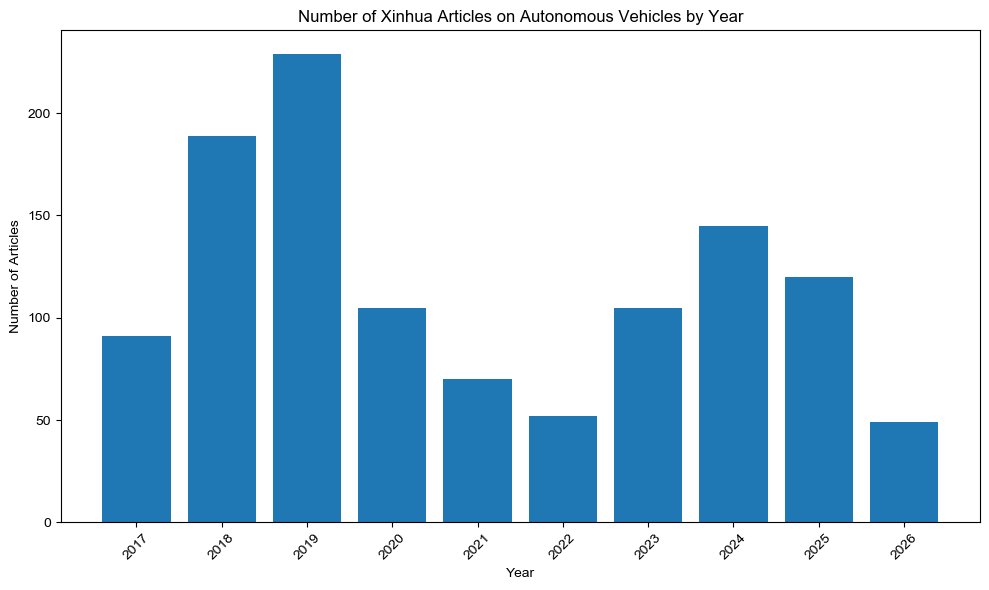

In [1545]:
# ============================================================
# 6. Article count by year
# ============================================================

year_counts = (
    data.groupby("year")
    .size()
    .reset_index(name="article_count")
    .sort_values("year")
)

display(year_counts)

year_counts.to_excel(OUTPUT_DIR / "article_count_by_year.xlsx", index=False)

plt.figure(figsize=(10, 6))
plt.bar(year_counts["year"].astype(str), year_counts["article_count"])
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.title("Number of Xinhua Articles on Autonomous Vehicles by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "article_count_by_year.png", dpi=300)
plt.show()

,month,article_count
0,2017-06,16
1,2017-07,9
2,2017-08,4
3,2017-09,17
4,2017-10,13
5,2017-11,17
6,2017-12,15
7,2018-01,15
8,2018-02,15
9,2018-03,16


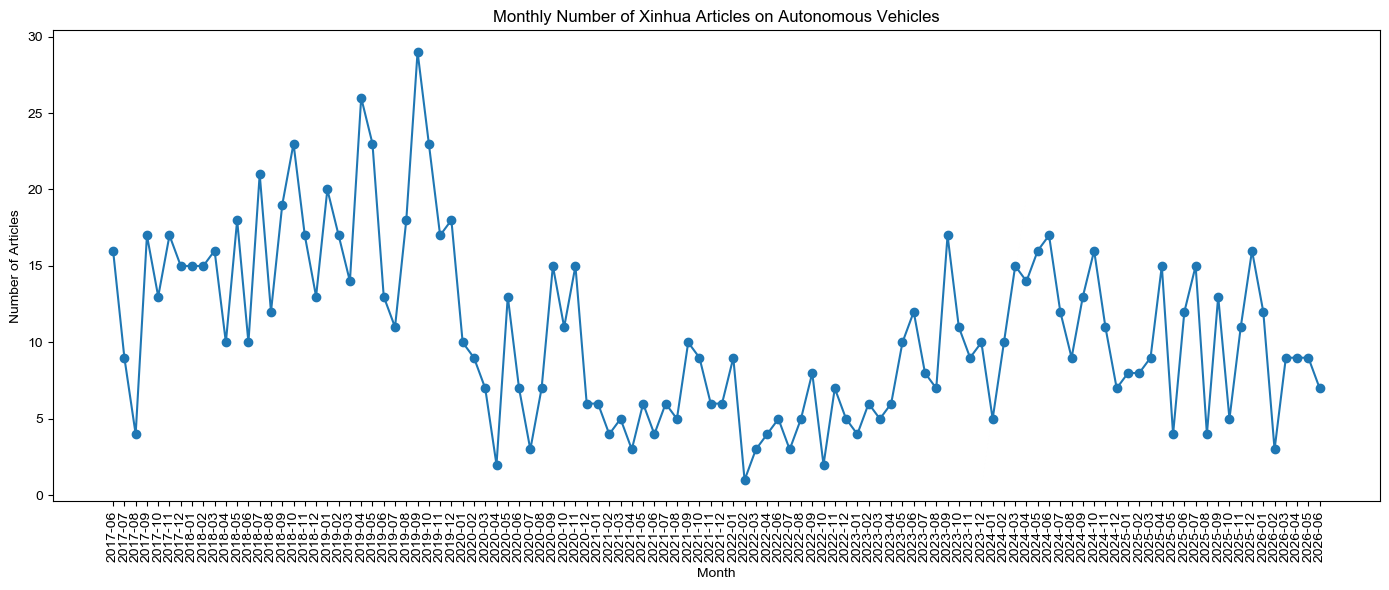

In [1546]:
# ============================================================
# Article count by month based on FINAL cleaned dataset
# ============================================================

month_counts_final = (
    data.groupby("month", dropna=False)
    .size()
    .reset_index(name="article_count")
    .sort_values("month")
)

display(month_counts_final)

month_counts_final.to_excel(
    OUTPUT_DIR / "article_count_by_month_final.xlsx",
    index=False
)

# ============================================================
# Plot monthly article counts based on FINAL cleaned dataset
# ============================================================

# Remove NaT rows for plotting
month_counts_plot = month_counts_final[
    month_counts_final["month"] != "NaT"
].copy()

plt.figure(figsize=(14, 6))
plt.plot(
    month_counts_plot["month"],
    month_counts_plot["article_count"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.title("Monthly Number of Xinhua Articles on Autonomous Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "article_count_by_month_final.png",
    dpi=300
)

plt.show()

,metric,content_char_length
0,count,1155.000000
1,mean,983.061472
2,std,577.739306
3,min,75.000000
4,25%,562.000000
5,50%,858.000000
6,75%,1286.500000
7,max,6615.000000


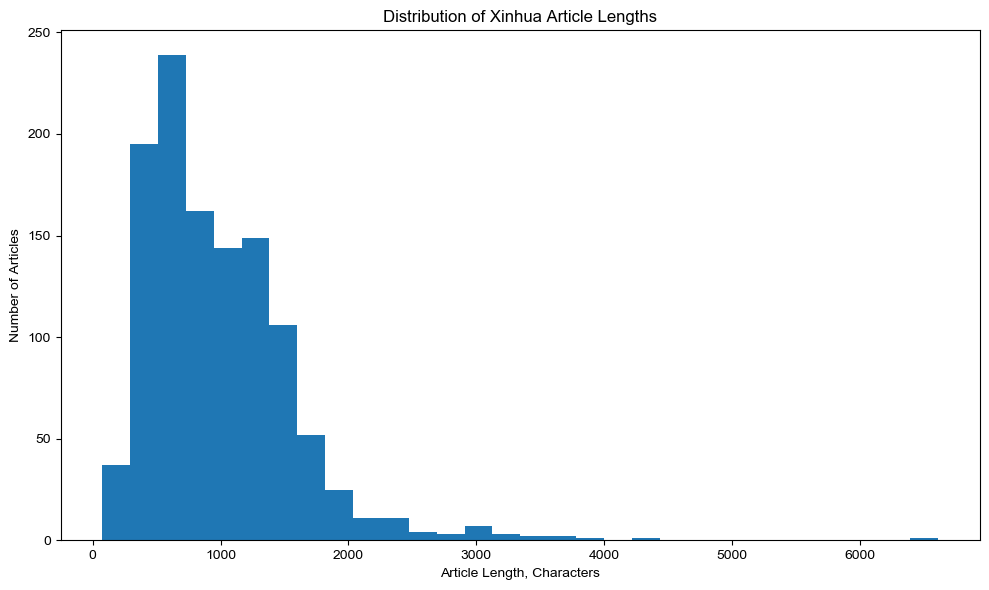

In [1547]:
# ============================================================
# 8. Article length distribution
# ============================================================

length_stats = data["content_char_length"].describe().reset_index()
length_stats.columns = ["metric", "content_char_length"]

display(length_stats)

length_stats.to_excel(OUTPUT_DIR / "article_length_stats.xlsx", index=False)

plt.figure(figsize=(10, 6))
plt.hist(data["content_char_length"], bins=30)
plt.xlabel("Article Length, Characters")
plt.ylabel("Number of Articles")
plt.title("Distribution of Xinhua Article Lengths")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "article_length_distribution.png", dpi=300)
plt.show()

In [1548]:
# ============================================================
# Show longest articles
# ============================================================

longest_articles = data.sort_values("content_char_length", ascending=False).copy()

cols_to_show = ["date_fixed", DATE_COL, TITLE_COL, "content_char_length", CONTENT_COL]
cols_to_show = [col for col in cols_to_show if col in data.columns]

display(longest_articles[cols_to_show].head(0))

longest_articles[cols_to_show].head(50).to_excel(
    OUTPUT_DIR / "top_50_longest_articles_check.xlsx",
    index=False
)

,date_fixed,date,title,content_char_length,article_content_clean


,keyword,title_count,content_count,total_articles_containing_keyword
0,自动驾驶,98,741,741
1,无人驾驶,43,506,506
20,新能源汽车,20,171,171
3,自动驾驶汽车,21,125,129
2,智能网联汽车,20,121,121
6,无人驾驶汽车,6,72,72
8,智能汽车,5,63,64
7,无人车,6,62,63
15,智能驾驶,5,61,62
9,车联网,2,60,60


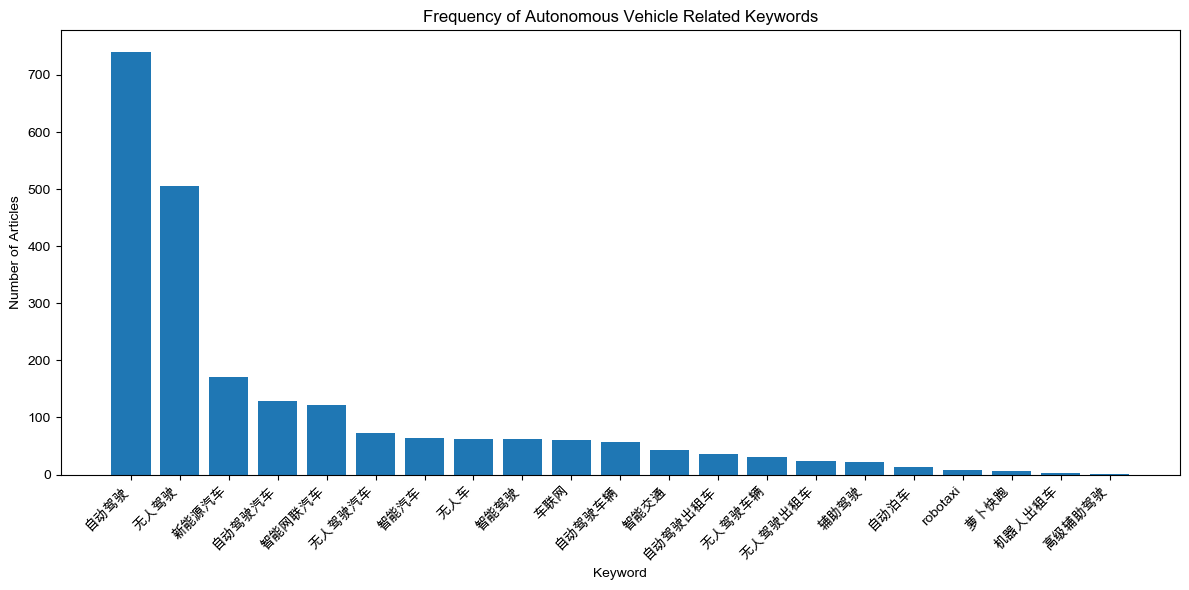

In [1549]:
import matplotlib.pyplot as plt
import matplotlib

# Mac 常用中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Songti SC"]
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 9. Keyword frequency
# ============================================================

keywords = [
    "自动驾驶",
    "无人驾驶",
    "智能网联汽车",
    "自动驾驶汽车",
    "自动驾驶车辆",
    "无人驾驶车辆",
    "无人驾驶汽车",
    "无人车",
    "智能汽车",
    "车联网",
    "机器人出租车",
    "robotaxi",
    "萝卜快跑",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "智能驾驶",
    "辅助驾驶",
    "自动泊车",
    "高级辅助驾驶",
    "智能交通",
    "新能源汽车"
]

keyword_counts = []

for kw in keywords:
    title_match = data[TITLE_COL].str.contains(
        kw, case=False, na=False, regex=False
    )
    content_match = data[CONTENT_COL].str.contains(
        kw, case=False, na=False, regex=False
    )
    
    keyword_counts.append({
        "keyword": kw,
        "title_count": title_match.sum(),
        "content_count": content_match.sum(),
        "total_articles_containing_keyword": (title_match | content_match).sum()
    })

keyword_counts_df = pd.DataFrame(keyword_counts).sort_values(
    "total_articles_containing_keyword",
    ascending=False
)

display(keyword_counts_df)

keyword_counts_df.to_excel(
    OUTPUT_DIR / "keyword_frequency.xlsx",
    index=False
)

# ------------------------------------------------------------
# Plot keyword frequency with Chinese font support
# ------------------------------------------------------------

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",
    "PingFang SC",
    "Heiti TC",
    "Songti SC"
]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

plt.bar(
    keyword_counts_df["keyword"],
    keyword_counts_df["total_articles_containing_keyword"]
)

plt.xlabel("Keyword")
plt.ylabel("Number of Articles")
plt.title("Frequency of Autonomous Vehicle Related Keywords")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "keyword_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,year,keyword,article_count
0,2017,自动驾驶,54
1,2017,无人驾驶,53
2,2017,智能网联汽车,7
3,2017,自动驾驶汽车,9
4,2017,自动驾驶车辆,3


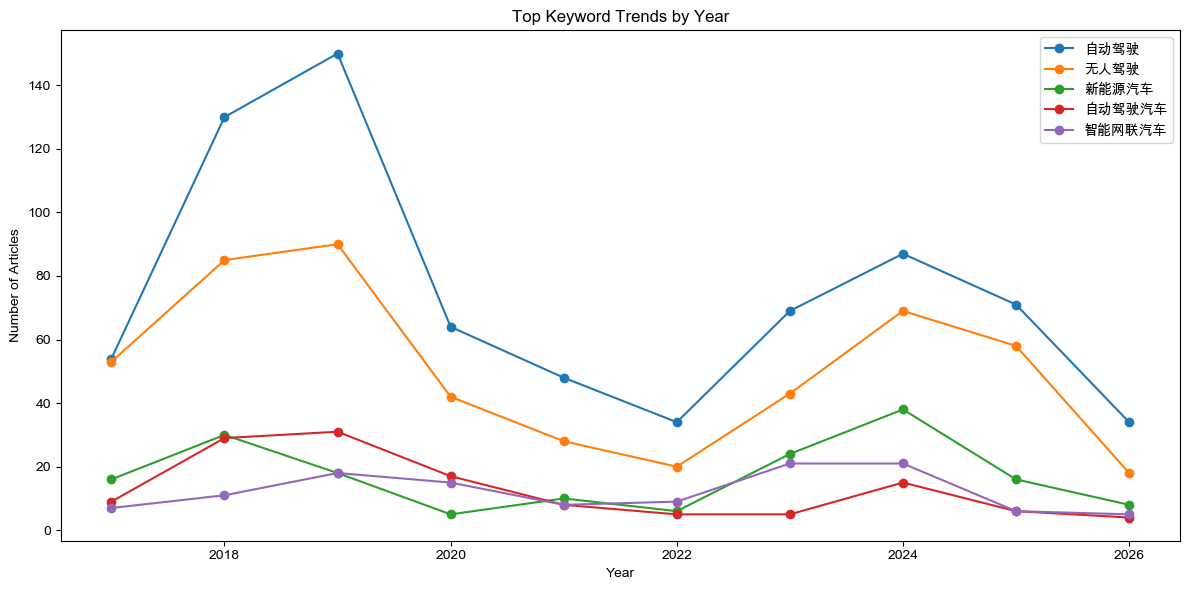

In [1550]:
# ============================================================
# 10. Keyword trends by year
# ============================================================

# Make sure Chinese characters display correctly in plots
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",
    "PingFang SC",
    "Heiti TC",
    "Songti SC"
]
plt.rcParams["axes.unicode_minus"] = False

keyword_trend_rows = []

for year, group in data.groupby("year"):
    for kw in keywords:
        title_match = group[TITLE_COL].str.contains(
            kw, case=False, na=False, regex=False
        )
        content_match = group[CONTENT_COL].str.contains(
            kw, case=False, na=False, regex=False
        )
        
        count = (title_match | content_match).sum()
        
        keyword_trend_rows.append({
            "year": year,
            "keyword": kw,
            "article_count": count
        })

keyword_trends = pd.DataFrame(keyword_trend_rows)

display(keyword_trends.head())

keyword_trends.to_excel(
    OUTPUT_DIR / "keyword_trends_by_year.xlsx",
    index=False
)

# ------------------------------------------------------------
# Plot top 5 keywords only
# ------------------------------------------------------------

top_keywords = keyword_counts_df.head(5)["keyword"].tolist()

plt.figure(figsize=(12, 6))

for kw in top_keywords:
    temp = keyword_trends[
        keyword_trends["keyword"] == kw
    ].sort_values("year")
    
    plt.plot(
        temp["year"],
        temp["article_count"],
        marker="o",
        label=kw
    )

plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.title("Top Keyword Trends by Year")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_keyword_trends_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1551]:
# ============================================================
# 11. Simple frequent term extraction
# ============================================================

# Basic Chinese stopwords
stopwords = set([
    "新华社", "记者", "报道", "表示", "介绍", "目前", "相关", "进行", "通过",
    "一个", "一种", "一些", "以及", "其中", "可以", "已经", "成为", "记者从",
    "中国", "我国", "发展", "建设", "服务", "企业", "城市", "技术", "汽车"
])

def extract_chinese_terms(text, min_len=2, max_len=4):
    text = str(text)
    chinese_text = "".join(re.findall(r"[\u4e00-\u9fff]+", text))
    
    terms = []
    for n in range(min_len, max_len + 1):
        for i in range(len(chinese_text) - n + 1):
            term = chinese_text[i:i+n]
            if term not in stopwords:
                terms.append(term)
    return terms

all_terms = []

for text in data[CONTENT_COL].dropna():
    all_terms.extend(extract_chinese_terms(text, min_len=2, max_len=4))

term_counts = Counter(all_terms)

top_terms_df = pd.DataFrame(term_counts.most_common(100), columns=["term", "count"])

display(top_terms_df.head(30))

top_terms_df.to_excel(OUTPUT_DIR / "top_terms_simple_extraction.xlsx", index=False)

,term,count
0,智能,4597
1,驾驶,3468
2,自动,2646
3,公司,2248
4,产业,2227
5,动驾,2020
6,动驾驶,2020
7,自动驾,2017
8,自动驾驶,2017
9,创新,2011


In [1552]:
import pandas as pd
import re
from pathlib import Path

BASE_DIR = Path("/Users/yurujia/Desktop/Dissertation Data/China")
DESC_DIR = BASE_DIR / "descriptive_stats"
EXCEL_DIR = BASE_DIR / "excel"

final_data_path = DESC_DIR / "xinhua_av_final_analytical_dataset.xlsx"
old_sample_path = EXCEL_DIR / "manual_sentiment_sample_220_av_sentiment.xlsx"

final_df = pd.read_excel(final_data_path)
old_sample = pd.read_excel(old_sample_path)

TITLE_COL = "title"

def normalize_title(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", "", x)
    x = x.replace("：", ":")
    x = x.replace("，", ",")
    x = x.replace("（", "(").replace("）", ")")
    return x

final_df["_title_key"] = final_df[TITLE_COL].apply(normalize_title)
old_sample["_title_key"] = old_sample[TITLE_COL].apply(normalize_title)

old_titles = set(old_sample["_title_key"])
final_titles = set(final_df["_title_key"])

matched_titles = old_titles.intersection(final_titles)

print("Old sample rows:", len(old_sample))
print("Unique old sample titles:", old_sample["_title_key"].nunique())
print("Final dataset rows:", len(final_df))
print("Unique final titles:", final_df["_title_key"].nunique())
print("Old sample titles still in final dataset:", len(matched_titles))
print("Old sample titles removed/not matched:", old_sample["_title_key"].nunique() - len(matched_titles))

Old sample rows: 220
Unique old sample titles: 219
Final dataset rows: 1155
Unique final titles: 1154
Old sample titles still in final dataset: 115
Old sample titles removed/not matched: 104


Data loaded successfully.
Shape: (1155, 54)

Columns:
['file', 'title', 'source', 'date', 'content', 'source_file', 'has_body_marker', 'has_wan_marker', 'has_load_date_marker', 'article_content_clean', 'extraction_method', 'extract_success', 'date_original', 'date_fixed', 'date_parsed_direct', 'year_temp', 'month_temp', 'content_char_length', 'approx_token_count', 'exclude_title_keyword', 'exclude_too_long', 'exclude_from_analysis', 'exclusion_reason', 'has_explicit_brief_title', 'has_explicit_brief_header', 'small_heading_count', 'has_multiple_small_headings', 'exclude_multi_topic_brief', 'multi_topic_brief_exclusion_reason', 'automated_screen_text', 'has_general_road_av_term', 'has_higher_automation_term', 'has_passenger_robotaxi_term', 'has_strong_passenger_robotaxi_term', 'has_bus_public_transport_term', 'has_adas_term', 'has_road_vehicle_context', 'has_strong_non_road_term', 'has_general_non_road_context', 'has_non_road_primary_topic_term', 'has_non_road_term', 'remove_no_relevant

,title,skipped_metadata_text,first_paragraph_before_dateline_removal,first_paragraph,xinhua_dateline_removed,extraction_candidate_position,first_paragraph_char_count,first_paragraph_chinese_char_count,first_paragraph_approx_text_unit_count,first_paragraph_extracted,first_paragraph_prefix_problem,article_content_clean
0,（财经）专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌,新华社柏林６月１日电专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌 | 新华社记者乔继红 朱晟,中国和德国在电动汽车领域各有优势，两国车企如果能够融合优势，将创造领先全球的强大竞争力，未来中德电动汽车的合作远大于竞争。中国智能电动汽车公司蔚来汽车董事长、创始人李斌接受新华社记者专访时如是说。,中国和德国在电动汽车领域各有优势，两国车企如果能够融合优势，将创造领先全球的强大竞争力，未来中德电动汽车的合作远大于竞争。中国智能电动汽车公司蔚来汽车董事长、创始人李斌接受新华社记者专访时如是说。,False,3,98,92,92,True,False,新华社柏林６月１日电专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌\n新华社记者乔继红 朱晟\n中国和德国在电动汽车领域各有优势，两国车企如果能够融合优势，将创造领先全球的强大竞争力，未来中德电动汽车的合作远大于竞争。中国智能电动汽车公司蔚来汽车董事长、创始人李斌接受新华社记者专访时如是说。\n在李克强总理访问德国期间，蔚来汽车５月３１日在柏林与德国大陆集团签署战略合作协议，主要涉及电动汽车零部件供应、无人驾驶技术合作和推动空气悬挂系统在中国本土化生产等，首期合同金额４５亿元人民币。“这是大陆集团与新能源汽车公司签署的最大战略合作协议。”李斌说。\n李斌说，李克强总理此次访问德国对中国企业界来说是一件大事，对促进中德电动汽车领域的合作有巨大推动作用。\n除了蔚来携手大陆集团，江淮汽车与德国大众汽车、北汽集团和德国奔驰集团也分别签署了电动汽车合作协议。\n蔚来汽车成立于２０１４年，是源自中国的全球初创公司，投资方主要来自京东、腾讯和百度等中国高科技、互联网行业企业。李斌说，蔚来的市场定位是高性能智能电动汽车，已在慕尼黑、伦敦、硅谷等全球多地设立设计和研发中心，目标是...
1,（李克强出访配合稿）专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东,新华社柏林６月２日电专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东 | 新华社记者严锋 朱晟,“经贸合作始终是中德关系的压舱石。李克强总理此访在经贸领域取得了丰硕的成果，必将推动中德经贸合作迈上新台阶。”中国驻德国大使馆经商处公使衔参赞王卫东２日接受新华社记者专访时说。,“经贸合作始终是中德关系的压舱石。李克强总理此访在经贸领域取得了丰硕的成果，必将推动中德经贸合作迈上新台阶。”中国驻德国大使馆经商处公使衔参赞王卫东２日接受新华社记者专访时说。,False,3,88,81,82,True,False,新华社柏林６月２日电专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东\n新华社记者严锋 朱晟\n“经贸合作始终是中德关系的压舱石。李克强总理此访在经贸领域取得了丰硕的成果，必将推动中德经贸合作迈上新台阶。”中国驻德国大使馆经商处公使衔参赞王卫东２日接受新华社记者专访时说。\n中国国务院总理李克强于５月３１日至６月１日对德国进行正式访问并成功举行中德总理年度会晤。\n王卫东认为，李克强总理此访正好处在全球化进程遭遇“逆风”、贸易保护主义抬头的大背景下，各方都对中德两国的立场充满期待。在访问中，中德双方均明确表示要共同促进贸易自由化和投资便利化，支持尽早缔结中欧投资协定和开启中欧自由贸易合作。两国同意在二十国集团框架下密切配合，推动二十国集团汉堡峰会取得成功，共同为推进全球经济治理作出贡献。两国领导人在维护自由贸易体制、促进经济全球化等问题上发出共同声音，为建设开放型世界经济注入了“正能量”，具有“风向标”和“稳定器”的重要意义。\n王卫东希望，在默克尔总理公开表态支持世界贸易组织的原则和规则、支持欧盟履行《中国加入世界贸易组织议定书》第１５条义务的同时，德国...
2,中国新能源汽车全球占比一半,,新华社北京６月６日电（记者陈芳 董瑞丰）通过手机定位，找到距离最近的电动汽车，用手机开锁后就可以驾驶，直至停下来留给下一位客户使用。６日在北京召开的２０１７国际电动汽车示范城市及产业发展论坛上，中国科技部部长万钢描绘了这样一个场景。,通过手机定位，找到距离最近的电动汽车，用手机开锁后就可以驾驶，直至停下来留给下一位客户使用。６日在北京召开的２０１７国际电动汽车示范城市及产业发展论坛上，中国科技部部长万钢描绘了这样一个场景。,True,1,96,85,87,True,False,新华社北京６月６日电（记者陈芳 董瑞丰）通过手机定位，找到距离最近的电动汽车，用手机开锁后就可以驾驶，直至停下来留给下一位客户使用。６日在北京召开的２０１７国际电动汽车示范城市及产业发展论坛上，中国科技部部长万钢描绘了这样一个场景。\n作为第八届清洁能源部长级会议暨第二届创新使命部长级会议的重要边会之一——２０１７国际电动汽车示范城市及产业发展论坛以“深化全球多边化合作，推动交通电动化转型”为主题，来自中国、美国、英国、法国、德国等国家及地区的３００余名嘉宾参加会议。\n科技部的数据显示，到去年年底，中国新能源汽车的产量突破５０万辆，保有量超过１００万辆，在全球的占比都达到了５０％。\n万钢说，这是中国推动电动汽车发展的重大示范行动，未来将积极做好充电基础设施建设、车辆安全、减排效应、电动汽车回收利用等方面的工作。\n万钢表示，中国电动汽车在关键零部件、动力电池产业化等诸多方面取得了快速发展，自２０１０年大规模牵头发展电动汽车以来，每隔４年左右，中国电动汽车电池的能量密度就能提高１倍、成本约降低５０％。\n“我们正在逐渐把自动驾驶融入电动汽车这个重大专项、融入未来电动汽车产品当...
3,（科技）专家：自动驾驶技术有望让交通事故零伤亡,,新华社瑞典哥德堡６月７日电（记者潘革平 付一鸣）吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动驾驶技术有助避免交通事故，到２０２０年甚至可以实现交通事故零伤亡。,吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动驾驶技术有助避免交通事故，到２０２０年甚至可以实现交通事故零伤亡。,True,1,79,72,73,True,False,新华社瑞典哥德堡６月７日电（记者潘革平 付一鸣）吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动驾驶技术有助避免交通事故，到２０２０年甚至可以实现交通事故零伤亡。\n吉利欧洲研发中心２０１３年由中国吉利集团和瑞典沃尔沃汽车集团联合成立，目的是为未来汽车开发新技术。据悉，一向注重安全的沃尔沃将在被动安全、主动安全以及自动驾驶系统等方面为汽车设置６道安全屏障。\n方浩瀚说：“通过在汽车中安装（自动驾驶）系统，比如传感器、雷达和读取交通状况的系统，我们可以在非常困难的交通状况下依然安全行驶，这很大程度上避免了事故发生，从而真正将交通事故的风险降至几乎为零。这就是沃尔沃提出２０２０年零伤亡愿景的原因。”\n他说：“依靠摄像头、传感器和其他新技术，汽车已经可以在高速公路上自动驾驶而且相当安全。但是在大城市或复杂交通状况下，自动驾驶遇到的挑战更大。”他预测，自动驾驶推广的第一步，很可能是在城市中规划供自动驾驶汽车通行的特殊车道，而随着相关技术逐步成熟，再实现复杂交通状况下的自动驾驶。\n本月２日在比利时布鲁塞尔举行的吉利沃尔沃汽车创新成果展上展出...
4,（财经）日本预计于２０２３年普及５Ｇ通信,,新华社东京６月７日电（记者钱铮）下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至日本全境，这将加速自动驾驶车辆和物联网在日本的普及。,下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至日本全境，这将加速自动驾驶车辆和物联网在日本的普及。,True,1,72,60,62,True,False,新华社东京６月７日电（记者钱铮）下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至日本全境，这将加速自动驾驶车辆和物联网在日本的普及。\n据《日本经济新闻》７日报道，为配合２０２０年东京奥运会的举行，日本三大无线通信运营商都科摩通信公司、凯迪迪爱公司和软银公司计划届时在东京都中心城区等区域率先提供５Ｇ服务，并用３年时间逐步推广到全国。\n三家公司计划从２０１９年度起开始设备投资，并完善针对５Ｇ的软硬件环境，包括全国基站的部件、服务器、专用系统等，总投资额估计将达５万亿日元（１美元约合１１０日元）规模。\n５Ｇ技术的通信速度最大可达４Ｇ技术的１００倍左右，其在自动驾驶、远程医疗、物联网等领域的应用前景被广泛看好。



Articles where no first paragraph was extracted: 0
Successfully extracted paragraphs with zero Chinese characters: 0
Extracted first paragraphs with fewer than 20 Chinese characters: 29
Extracted first paragraphs longer than 1,000 characters: 0

Remaining articles with exactly 3 or 5 Chinese characters:
0

Paragraph sample definitions:
Successfully extracted first paragraphs: 1155
Extracted paragraphs containing Chinese characters: 1155
Failed first-paragraph extractions: 0


,metric,value
0,Total articles,1155.00
1,Successfully extracted first paragraphs,1155.00
2,Failed first-paragraph extractions,0.00
3,Extraction success rate (%),100.00
4,Extracted paragraphs containing Chinese characters,1155.00
5,Extracted paragraphs excluded from Chinese-character statistics because they contain zero Chinese characters,0.00
6,Articles with skipped metadata lines,399.00
7,Total metadata lines skipped,794.00
8,Paragraphs where Xinhua dateline/byline prefix was removed,753.00
9,Paragraphs with possible remaining metadata or prefix,1.00


,variable,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
0,first_paragraph_char_count,1155.0,85.154978,32.277357,4.0,47.0,63.0,84.0,104.0,126.0,139.0,171.46,296.0
1,first_paragraph_chinese_char_count,1155.0,73.207792,28.340865,4.0,40.0,55.0,72.0,90.0,107.0,121.3,146.84,260.0
2,first_paragraph_english_word_count,1155.0,0.288312,0.790428,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.00,7.0
3,first_paragraph_number_count,1155.0,1.807792,1.963561,0.0,0.0,0.0,1.0,3.0,4.0,6.0,8.00,17.0
4,first_paragraph_approx_text_unit_count,1155.0,75.303896,28.691213,4.0,41.4,57.0,74.0,92.0,110.0,123.3,151.00,260.0


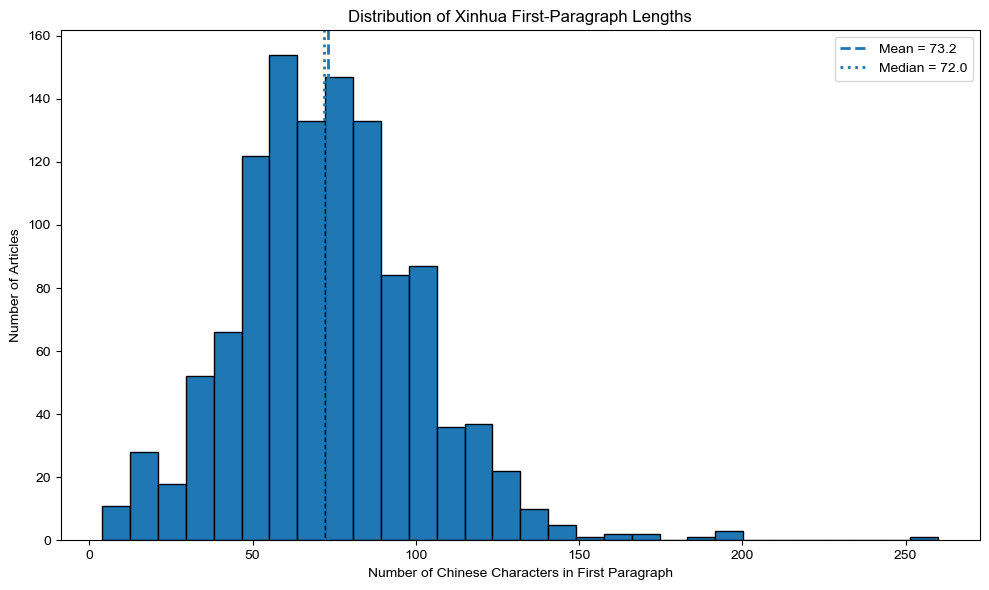


FIRST-PARAGRAPH EXTRACTION COMPLETED

Input file:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_av_final_analytical_dataset.xlsx

Text column used:
article_content_clean

Total articles:
1155

Successfully extracted:
1155

Used for Chinese-character statistics:
1155

Failed extractions:
0

Articles with skipped metadata:
399

Total metadata lines skipped:
794

Articles where Xinhua dateline/byline prefix was removed:
753

Articles with possible remaining metadata or prefix:
1

Successfully extracted paragraphs with zero Chinese characters:
0

Remaining articles with exactly 3 or 5 Chinese characters:
0

Mean Chinese-character count:
73.21

Median Chinese-character count:
72.0

Final dataset saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_av_final_with_first_paragraph.xlsx

Descriptive statistics saved to:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/first_paragraph_descriptive_stats.xlsx

Extraction-check 

In [1553]:
# %%
# ============================================================
# Extract First Substantive Paragraph from Xinhua Articles
#
# This version:
# 1. Skips titles, headings and standalone bylines
# 2. Skips standalone dates and known Xinhua metadata lines
# 3. Conservatively removes Xinhua dateline prefixes
# 4. Continues to the next paragraph when metadata is encountered
# 5. Calculates paragraph length and descriptive statistics
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re


# ============================================================
# 1. File paths
# ============================================================

BASE_DIR = Path(
    "/Users/yurujia/Desktop/Dissertation Data/China"
)

OUTPUT_DIR = BASE_DIR / "descriptive_stats"

INPUT_PATH = (
    OUTPUT_DIR / "xinhua_av_final_analytical_dataset.xlsx"
)

OUTPUT_DATA_PATH = (
    OUTPUT_DIR / "xinhua_av_final_with_first_paragraph.xlsx"
)

OUTPUT_STATS_PATH = (
    OUTPUT_DIR / "first_paragraph_descriptive_stats.xlsx"
)

OUTPUT_CHECK_PATH = (
    OUTPUT_DIR / "first_paragraph_extraction_check.xlsx"
)

OUTPUT_FAILED_PATH = (
    OUTPUT_DIR / "first_paragraph_extraction_failed_check.xlsx"
)

OUTPUT_PREFIX_PROBLEM_PATH = (
    OUTPUT_DIR / "first_paragraph_remaining_prefix_check.xlsx"
)

OUTPUT_ZERO_LENGTH_PATH = (
    OUTPUT_DIR / "first_paragraph_zero_length_check.xlsx"
)

OUTPUT_SKIPPED_METADATA_PATH = (
    OUTPUT_DIR / "first_paragraph_skipped_metadata_check.xlsx"
)

OUTPUT_SHORT_PATH = (
    OUTPUT_DIR / "first_paragraph_under_20_chars_check.xlsx"
)

OUTPUT_HISTOGRAM_PATH = (
    OUTPUT_DIR / "first_paragraph_length_distribution.png"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# %%
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_excel(INPUT_PATH)

print("Data loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# %%
# ============================================================
# 3. Define key columns
# ============================================================

TITLE_COL = "title"

# Prefer cleaned article content.
# Use content only as a fallback.
if "article_content_clean" in df.columns:

    TEXT_COL = "article_content_clean"

elif "content" in df.columns:

    TEXT_COL = "content"

    print(
        "\nWARNING: 'article_content_clean' was not found."
        "\nThe code will use the 'content' column instead."
    )

else:

    raise ValueError(
        "Neither 'article_content_clean' nor 'content' exists.\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )


if TITLE_COL not in df.columns:

    print(
        "\nWARNING: 'title' column was not found. "
        "Title-based filtering will be skipped."
    )

    df[TITLE_COL] = ""


print("\nText column used:", TEXT_COL)


# Ensure string format
df[TEXT_COL] = (
    df[TEXT_COL]
    .fillna("")
    .astype(str)
)

df[TITLE_COL] = (
    df[TITLE_COL]
    .fillna("")
    .astype(str)
)


# %%
# ============================================================
# 4. General helper functions
# ============================================================

def normalize_for_comparison(text):
    """
    Normalize text for comparison.

    This removes whitespace and standardizes selected punctuation,
    but preserves substantive characters.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Convert full-width spaces to ordinary spaces
    text = text.replace("\u3000", " ")

    # Remove surrounding spreadsheet quotation marks
    text = (
        text
        .strip()
        .strip('"')
        .strip("'")
    )

    # Remove all whitespace
    text = re.sub(
        r"\s+",
        "",
        text
    )

    # Standardize common punctuation
    text = text.replace("：", ":")
    text = text.replace("，", ",")
    text = text.replace("（", "(")
    text = text.replace("）", ")")

    return text


def clean_line(line):
    """
    Basic cleaning for one candidate paragraph.
    """

    if pd.isna(line):
        return ""

    line = str(line)

    # Convert full-width spaces
    line = line.replace("\u3000", " ")

    # Normalize tabs and repeated spaces
    line = re.sub(
        r"[ \t]+",
        " ",
        line
    )

    # Remove surrounding spaces and spreadsheet quotation marks
    line = (
        line
        .strip()
        .strip('"')
        .strip("'")
        .strip()
    )

    return line


def is_same_as_title(line, title):
    """
    Check whether a paragraph repeats the article title.
    """

    line_key = normalize_for_comparison(line)
    title_key = normalize_for_comparison(title)

    if not line_key or not title_key:
        return False

    # Exact normalized match
    if line_key == title_key:
        return True

    # Allow punctuation differences
    punctuation_pattern = (
        r"[，。！？；：、“”‘’《》〈〉（）()\-—,:;!?]"
    )

    line_key_no_punctuation = re.sub(
        punctuation_pattern,
        "",
        line_key
    )

    title_key_no_punctuation = re.sub(
        punctuation_pattern,
        "",
        title_key
    )

    return (
        line_key_no_punctuation
        == title_key_no_punctuation
        and len(title_key_no_punctuation) >= 8
    )


# %%
# ============================================================
# 5. Known Xinhua metadata lines
# ============================================================

# These are skipped only when the entire candidate paragraph
# equals one of these values after normalization.
KNOWN_METADATA_LINES = {
    "全选",
    "港澳台简讯",
    "新华社记者",
    "辛识平",
    "钟华论",
    "姜天麒",

    # Other common Xinhua labels or commentary brands
    "新华时评",
    "新华述评",
    "新华国际时评",
    "新华财经",
    "新华全媒",
    "新华全媒头条",
    "新华全媒＋",
    "新华全媒+",
    "新华视点",
    "新华调查",
    "新华解码",
    "新华观察",
    "国际观察",
    "新闻分析",
    "记者手记",
    "新闻背景",
    "背景资料",
    "核心提示",
    "图片说明",
}

KNOWN_METADATA_NORMALIZED = {
    normalize_for_comparison(item)
    for item in KNOWN_METADATA_LINES
}


def is_date_only_line(line):
    """
    Identify a line containing only a date.

    Examples:
    （2024年8月30日）
    (2024年8月30日)
    2024年8月30日
    （２０２４年８月３０日）
    """

    compact = normalize_for_comparison(line)

    date_only_patterns = [
        # Chinese date, optionally enclosed in parentheses
        r"^[（(]?"
        r"[0-9０-９]{4}年"
        r"[0-9０-９]{1,2}月"
        r"[0-9０-９]{1,2}日"
        r"[）)]?$",

        # Date without year
        r"^[（(]?"
        r"[0-9０-９]{1,2}月"
        r"[0-9０-９]{1,2}日"
        r"[）)]?$",

        # ISO-style date
        r"^[（(]?"
        r"[0-9０-９]{4}"
        r"[-./]"
        r"[0-9０-９]{1,2}"
        r"[-./]"
        r"[0-9０-９]{1,2}"
        r"[）)]?$",
    ]

    return any(
        re.fullmatch(
            pattern,
            compact
        )
        for pattern in date_only_patterns
    )


def is_known_metadata_line(line):
    """
    Identify a standalone known metadata line.

    This uses exact normalized matching so that a term such as
    '新华社记者' appearing inside a substantive sentence is not
    automatically deleted.
    """

    compact = normalize_for_comparison(line)

    if compact == "":
        return False

    if compact in KNOWN_METADATA_NORMALIZED:
        return True

    if is_date_only_line(line):
        return True

    return False


# %%
# ============================================================
# 6. Standalone byline detection
# ============================================================

def is_byline(line):
    """
    Identify standalone journalist or byline lines.

    Examples:
    新华社记者严锋 朱晟
    新华社记者冯雷、闫平、孙仁斌
    记者张三 李四
    文／新华社记者张三
    """

    compact = re.sub(
        r"\s+",
        "",
        str(line)
    )

    # Exact metadata such as 新华社记者
    if is_known_metadata_line(line):
        return True

    byline_patterns = [
        # 新华社记者张三
        # 新华社记者张三、李四
        r"^新华社记者"
        r"[\u4e00-\u9fff、，,·•]{2,40}$",

        # 记者张三
        # 记者张三、李四
        r"^记者"
        r"[\u4e00-\u9fff、，,·•]{2,40}$",

        # 通讯员张三
        r"^(?:通讯员|特约记者|实习记者)"
        r"[\u4e00-\u9fff、，,·•]{2,40}$",

        # 新华社张三记者
        r"^新华社"
        r"[\u4e00-\u9fff、，,·•]{2,40}"
        r"记者$",

        # 文／新华社记者张三
        r"^[文图摄影摄像／/：:]+"
        r"新华社记者"
        r"[\u4e00-\u9fff、，,·•]{2,40}$",

        # 文／记者张三
        r"^[文图摄影摄像／/：:]+"
        r"记者"
        r"[\u4e00-\u9fff、，,·•]{2,40}$",

        # 新华社记者：
        r"^新华社记者[：:]$",

        # 记者：
        r"^记者[：:]$",
    ]

    return any(
        re.fullmatch(
            pattern,
            compact
        )
        for pattern in byline_patterns
    )


# %%
# ============================================================
# 7. Heading and short-title detection
# ============================================================

def is_heading_or_metadata(line):
    """
    Identify headings or metadata that should not be treated as
    the first substantive paragraph.
    """

    compact = re.sub(
        r"\s+",
        "",
        str(line)
    )

    if is_known_metadata_line(line):
        return True

    heading_patterns = [
        # Dateline followed by article-type heading
        r"^新华社.*?电"
        r"(?:专访|题|特写|通讯|述评|综述|评论|"
        r"新华时评|新闻分析|国际观察|热点问答|财经观察|"
        r"年终报道|新春走基层)"
        r"[：:]",

        # Standalone headings
        r"^[（(]?小标题[）)]?[：:]?$",
        r"^[（(]?标题[）)]?[：:]?$",
        r"^题[：:]",
        r"^专访[：:]",
        r"^特写[：:]",
        r"^通讯[：:]",
        r"^述评[：:]",
        r"^综述[：:]",
        r"^评论[：:]",
        r"^新华时评[：:]",
        r"^新闻分析[：:]",
        r"^国际观察[：:]",
        r"^热点问答[：:]",
        r"^财经观察[：:]",
    ]

    return any(
        re.search(
            pattern,
            compact,
            flags=re.IGNORECASE
        )
        for pattern in heading_patterns
    )


def is_probable_short_title(line):
    """
    Conservatively identify a probable standalone short title.
    """

    compact = re.sub(
        r"\s+",
        "",
        str(line)
    )

    if is_known_metadata_line(line):
        return True

    has_sentence_end = bool(
        re.search(
            r"[。！？!?]$",
            compact
        )
    )

    title_markers = [
        "——",
        "专访：",
        "专访:",
        "题：",
        "题:",
        "特写：",
        "特写:",
        "述评：",
        "述评:",
        "通讯：",
        "通讯:",
    ]

    has_title_marker = any(
        marker in compact
        for marker in title_markers
    )

    return (
        len(compact) <= 80
        and not has_sentence_end
        and has_title_marker
    )


# %%
# ============================================================
# 8. Conservatively remove Xinhua dateline/byline prefixes
# ============================================================

def remove_xinhua_dateline_prefix(paragraph):
    """
    Conservatively remove a Xinhua dateline and clearly formatted
    reporter information from the beginning of a paragraph.

    Examples
    --------
    新华社北京6月20日电（记者张三）某公司20日宣布……
    -> 某公司20日宣布……

    新华社柏林６月２日电（记者张三、李四）“经贸合作……”
    -> “经贸合作……”

    The function avoids broad patterns that might delete
    substantive article content.

    Returns
    -------
    cleaned_text, prefix_removed
    """

    if pd.isna(paragraph):
        return "", False

    original_text = clean_line(paragraph)

    if original_text == "":
        return "", False

    text = original_text

    # --------------------------------------------------------
    # A. Remove Xinhua dateline
    # --------------------------------------------------------

    dateline_patterns = [
        # With year
        r"^新华社"
        r".{1,40}?"
        r"[0-9０-９]{4}年"
        r"[0-9０-９]{1,2}月"
        r"[0-9０-９]{1,2}日"
        r"电"
        r"\s*",

        # Without year
        r"^新华社"
        r".{1,40}?"
        r"[0-9０-９]{1,2}月"
        r"[0-9０-９]{1,2}日"
        r"电"
        r"\s*",
    ]

    for pattern in dateline_patterns:

        new_text = re.sub(
            pattern,
            "",
            text,
            count=1
        )

        if new_text != text:

            text = new_text.strip()
            break

    # --------------------------------------------------------
    # B. Remove reporter information only when enclosed
    #    in parentheses
    # --------------------------------------------------------

    bracketed_reporter_patterns = [
        # （记者张三）
        # （新华社记者张三、李四）
        r"^[（(]\s*(?:新华社)?记者"
        r"[^）)]{1,50}"
        r"[）)]"
        r"\s*",

        # （通讯员张三）
        # （特约记者张三）
        r"^[（(]\s*(?:新华社)?"
        r"(?:通讯员|特约记者|实习记者)"
        r"[^）)]{1,50}"
        r"[）)]"
        r"\s*",
    ]

    for pattern in bracketed_reporter_patterns:

        new_text = re.sub(
            pattern,
            "",
            text,
            count=1
        )

        if new_text != text:

            text = new_text.strip()
            break

    # --------------------------------------------------------
    # C. Remove only a highly specific non-bracketed reporter
    #    prefix followed by a clear separator
    # --------------------------------------------------------

    specific_reporter_prefix = (
        r"^(?:新华社)?记者"
        r"[\u4e00-\u9fff·•]{2,4}"
        r"(?:、[\u4e00-\u9fff·•]{2,4}){0,5}"
        r"(?:报道)?"
        r"[：:，,]"
        r"\s*"
    )

    new_text = re.sub(
        specific_reporter_prefix,
        "",
        text,
        count=1
    )

    if new_text != text:
        text = new_text.strip()

    # --------------------------------------------------------
    # D. Remove harmless punctuation left at the beginning
    # --------------------------------------------------------

    text = re.sub(
        r"^[：:，,；;、\s]+",
        "",
        text
    ).strip()

    prefix_removed = (
        normalize_for_comparison(text)
        != normalize_for_comparison(original_text)
    )

    return text, prefix_removed


# %%
# ============================================================
# 9. Extract first substantive paragraph
# ============================================================

def extract_first_substantive_paragraph(text, title=""):
    """
    Extract the first substantive paragraph.

    The function continues to the next candidate paragraph when
    it encounters:

    - article title
    - standalone date
    - known Xinhua metadata
    - columnist/commentary name
    - standalone journalist byline
    - heading
    - probable short title
    - paragraph containing only a dateline
    """

    result = {
        "first_paragraph_before_dateline_removal": "",
        "first_paragraph": "",
        "xinhua_dateline_removed": False,
        "extraction_candidate_position": pd.NA,
        "skipped_metadata_count": 0,
        "skipped_metadata_text": ""
    }

    if pd.isna(text):
        return result

    text = str(text)

    # Standardize newline formats
    text = text.replace("\r\n", "\n")
    text = text.replace("\r", "\n")

    # Convert literal \n sequences into real line breaks only
    # when no real line breaks exist
    if "\\n" in text and "\n" not in text:
        text = text.replace("\\n", "\n")

    # Remove surrounding spreadsheet quotation marks
    text = (
        text
        .strip()
        .strip('"')
        .strip("'")
    )

    # Split on one or more line breaks
    raw_paragraphs = re.split(
        r"\n+",
        text
    )

    paragraphs = []

    for raw_paragraph in raw_paragraphs:

        cleaned_paragraph = clean_line(
            raw_paragraph
        )

        if cleaned_paragraph != "":
            paragraphs.append(cleaned_paragraph)

    if not paragraphs:
        return result

    skipped_metadata = []

    for position, paragraph in enumerate(
        paragraphs,
        start=1
    ):

        # ----------------------------------------------------
        # Skip exact title repetition
        # ----------------------------------------------------

        if is_same_as_title(paragraph, title):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Skip known Xinhua metadata and standalone dates
        # ----------------------------------------------------

        if is_known_metadata_line(paragraph):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Skip standalone bylines
        # ----------------------------------------------------

        if is_byline(paragraph):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Skip headings and metadata
        # ----------------------------------------------------

        if is_heading_or_metadata(paragraph):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Skip probable short title
        # ----------------------------------------------------

        if is_probable_short_title(paragraph):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Remove dateline/byline prefix while retaining正文
        # ----------------------------------------------------

        cleaned_paragraph, prefix_removed = (
            remove_xinhua_dateline_prefix(
                paragraph
            )
        )

        # Candidate contained only metadata
        if cleaned_paragraph == "":
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Recheck after prefix removal
        # ----------------------------------------------------

        if is_same_as_title(cleaned_paragraph, title):
            skipped_metadata.append(paragraph)
            continue

        if is_known_metadata_line(cleaned_paragraph):
            skipped_metadata.append(paragraph)
            continue

        if is_byline(cleaned_paragraph):
            skipped_metadata.append(paragraph)
            continue

        if is_heading_or_metadata(cleaned_paragraph):
            skipped_metadata.append(paragraph)
            continue

        if is_probable_short_title(cleaned_paragraph):
            skipped_metadata.append(paragraph)
            continue

        # ----------------------------------------------------
        # Store valid first substantive paragraph
        # ----------------------------------------------------

        result[
            "first_paragraph_before_dateline_removal"
        ] = paragraph

        result[
            "first_paragraph"
        ] = cleaned_paragraph

        result[
            "xinhua_dateline_removed"
        ] = prefix_removed

        result[
            "extraction_candidate_position"
        ] = position

        result[
            "skipped_metadata_count"
        ] = len(skipped_metadata)

        result[
            "skipped_metadata_text"
        ] = " | ".join(skipped_metadata)

        return result

    # Store skipped metadata even if no paragraph was extracted
    result[
        "skipped_metadata_count"
    ] = len(skipped_metadata)

    result[
        "skipped_metadata_text"
    ] = " | ".join(skipped_metadata)

    return result


# Apply extraction
extraction_results = df.apply(
    lambda row: extract_first_substantive_paragraph(
        row[TEXT_COL],
        row[TITLE_COL]
    ),
    axis=1
)

# Convert returned dictionaries to DataFrame
extraction_results_df = pd.DataFrame(
    extraction_results.tolist(),
    index=df.index
)

# Add results to the main DataFrame
for column in extraction_results_df.columns:
    df[column] = extraction_results_df[column]


print("First-paragraph extraction completed.")

print(
    "\nNumber of articles where at least one metadata "
    "line was skipped:"
)

print(
    (
        df["skipped_metadata_count"] > 0
    ).sum()
)

print(
    "\nArticles where a Xinhua dateline/byline "
    "prefix was removed:"
)

print(
    df["xinhua_dateline_removed"]
    .value_counts(dropna=False)
)


# %%
# ============================================================
# 10. Paragraph length functions
# ============================================================

def count_non_whitespace_characters(text):
    """
    Count all characters excluding whitespace.
    """

    if pd.isna(text):
        return 0

    return len(
        re.sub(
            r"\s+",
            "",
            str(text)
        )
    )


def count_chinese_characters(text):
    """
    Count Chinese characters only.
    """

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"[\u4e00-\u9fff]",
            str(text)
        )
    )


def count_english_words(text):
    """
    Count English words.
    """

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"[A-Za-z]+(?:[-'][A-Za-z]+)*",
            str(text)
        )
    )


def count_numbers(text):
    """
    Count groups of Arabic or full-width numbers.
    """

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"[0-9０-９]+",
            str(text)
        )
    )


def count_mixed_text_units(text):
    """
    Approximate mixed-language text-unit count.

    Chinese characters
    + English words
    + number groups

    This is not an actual GPT tokenizer token count.
    """

    if pd.isna(text):
        return 0

    text = str(text)

    chinese_chars = re.findall(
        r"[\u4e00-\u9fff]",
        text
    )

    english_words = re.findall(
        r"[A-Za-z]+(?:[-'][A-Za-z]+)*",
        text
    )

    numbers = re.findall(
        r"[0-9０-９]+",
        text
    )

    return (
        len(chinese_chars)
        + len(english_words)
        + len(numbers)
    )


# %%
# ============================================================
# 11. Calculate paragraph lengths
# ============================================================

df["first_paragraph_char_count"] = (
    df["first_paragraph"]
    .apply(count_non_whitespace_characters)
)

df["first_paragraph_chinese_char_count"] = (
    df["first_paragraph"]
    .apply(count_chinese_characters)
)

df["first_paragraph_english_word_count"] = (
    df["first_paragraph"]
    .apply(count_english_words)
)

df["first_paragraph_number_count"] = (
    df["first_paragraph"]
    .apply(count_numbers)
)

df["first_paragraph_approx_text_unit_count"] = (
    df["first_paragraph"]
    .apply(count_mixed_text_units)
)

# Keep previous name for compatibility
df["first_paragraph_approx_token_count"] = (
    df["first_paragraph_approx_text_unit_count"]
)

df["first_paragraph_extracted"] = (
    df["first_paragraph"]
    .fillna("")
    .str
    .strip()
    .ne("")
)

print("\nExtraction status:")

print(
    df["first_paragraph_extracted"]
    .value_counts(dropna=False)
)


# %%
# ============================================================
# 12. Prefix and metadata audit variables
# ============================================================

df["first_paragraph_starts_with_xinhua"] = (
    df["first_paragraph"]
    .fillna("")
    .str
    .contains(
        r"^\s*新华社",
        regex=True,
        na=False
    )
)

df["first_paragraph_starts_with_byline"] = (
    df["first_paragraph"]
    .fillna("")
    .str
    .contains(
        r"^\s*(?:新华社)?"
        r"(?:记者|通讯员|特约记者|实习记者)"
        r"[\u4e00-\u9fff、，,·•]{2,20}"
        r"[：:]",
        regex=True,
        na=False
    )
)

df["first_paragraph_has_possible_dateline"] = (
    df["first_paragraph"]
    .fillna("")
    .str
    .contains(
        r"^\s*新华社"
        r".{0,40}?"
        r"[0-9０-９]{1,2}月"
        r"[0-9０-９]{1,2}日"
        r"电",
        regex=True,
        na=False
    )
)

df["first_paragraph_is_known_metadata"] = (
    df["first_paragraph"]
    .apply(is_known_metadata_line)
)

df["first_paragraph_prefix_problem"] = (
    df["first_paragraph_starts_with_xinhua"]
    | df["first_paragraph_starts_with_byline"]
    | df["first_paragraph_has_possible_dateline"]
    | df["first_paragraph_is_known_metadata"]
)

remaining_prefix_problems = df[
    df["first_paragraph_prefix_problem"]
].copy()

print(
    "\nExtracted paragraphs with possible remaining "
    "metadata, dateline or byline prefixes:"
)

print(len(remaining_prefix_problems))

remaining_prefix_problems.to_excel(
    OUTPUT_PREFIX_PROBLEM_PATH,
    index=False
)


# %%
# ============================================================
# 13. Export skipped metadata audit
# ============================================================

skipped_metadata_cases = df[
    df["skipped_metadata_count"] > 0
].copy()

skipped_metadata_columns = [
    "date_fixed",
    TITLE_COL,
    "skipped_metadata_count",
    "skipped_metadata_text",
    "first_paragraph_before_dateline_removal",
    "first_paragraph",
    "extraction_candidate_position",
    TEXT_COL
]

skipped_metadata_columns = [
    column
    for column in skipped_metadata_columns
    if column in skipped_metadata_cases.columns
]

skipped_metadata_cases[
    skipped_metadata_columns
].to_excel(
    OUTPUT_SKIPPED_METADATA_PATH,
    index=False
)

print(
    "\nSkipped metadata check file saved to:"
)

print(OUTPUT_SKIPPED_METADATA_PATH)


# %%
# ============================================================
# 14. Preview extracted paragraphs
# ============================================================

preview_columns = [
    TITLE_COL,
    "skipped_metadata_text",
    "first_paragraph_before_dateline_removal",
    "first_paragraph",
    "xinhua_dateline_removed",
    "extraction_candidate_position",
    "first_paragraph_char_count",
    "first_paragraph_chinese_char_count",
    "first_paragraph_approx_text_unit_count",
    "first_paragraph_extracted",
    "first_paragraph_prefix_problem",
    TEXT_COL
]

preview_columns = [
    column
    for column in preview_columns
    if column in df.columns
]

pd.set_option(
    "display.max_colwidth",
    500
)

pd.set_option(
    "display.width",
    250
)

display(
    df[preview_columns]
    .head(5)
)


# %%
# ============================================================
# 15. Identify possible extraction problems
# ============================================================

# Failed extraction
failed_extractions = df[
    ~df["first_paragraph_extracted"]
].copy()

print(
    "\nArticles where no first paragraph was extracted:",
    len(failed_extractions)
)

failed_extractions.to_excel(
    OUTPUT_FAILED_PATH,
    index=False
)


# ============================================================
# Successfully extracted paragraphs with zero Chinese characters
# ============================================================

# These rows have a non-empty extracted paragraph, but the
# extracted paragraph contains no Chinese characters.
#
# Failed extractions are excluded here because they are already
# stored separately in failed_extractions.
zero_chinese_extracted_paragraphs = df[
    df["first_paragraph_extracted"]
    & (
        df["first_paragraph_chinese_char_count"] == 0
    )
].copy()


print(
    "Successfully extracted paragraphs with zero Chinese characters:",
    len(zero_chinese_extracted_paragraphs)
)


zero_chinese_extracted_paragraphs.to_excel(
    OUTPUT_ZERO_LENGTH_PATH,
    index=False
)

# Very short extracted paragraphs
very_short_first_paragraphs = df[
    df["first_paragraph_extracted"]
    & (
        df["first_paragraph_chinese_char_count"] > 0
    )
    & (
        df["first_paragraph_chinese_char_count"] < 20
    )
].copy()

print(
    "Extracted first paragraphs with fewer than "
    "20 Chinese characters:",
    len(very_short_first_paragraphs)
)

short_check_columns = [
    "date_fixed",
    TITLE_COL,
    "skipped_metadata_text",
    "first_paragraph_before_dateline_removal",
    "first_paragraph",
    "first_paragraph_chinese_char_count",
    "extraction_candidate_position",
    TEXT_COL
]

short_check_columns = [
    column
    for column in short_check_columns
    if column in very_short_first_paragraphs.columns
]

very_short_first_paragraphs[
    short_check_columns
].to_excel(
    OUTPUT_SHORT_PATH,
    index=False
)


# Very long extracted paragraphs
very_long_first_paragraphs = df[
    df["first_paragraph_char_count"] > 1000
].copy()

print(
    "Extracted first paragraphs longer than "
    "1,000 characters:",
    len(very_long_first_paragraphs)
)


# %%
# ============================================================
# 16. Check whether 3-character and 5-character metadata remain
# ============================================================

three_or_five_check = df[
    df["first_paragraph_chinese_char_count"].isin(
        [3, 5]
    )
].copy()

print(
    "\nRemaining articles with exactly 3 or 5 "
    "Chinese characters:"
)

print(len(three_or_five_check))

if len(three_or_five_check) > 0:

    display_columns = [
        TITLE_COL,
        "skipped_metadata_text",
        "first_paragraph_before_dateline_removal",
        "first_paragraph",
        "first_paragraph_chinese_char_count",
        "extraction_candidate_position",
        TEXT_COL
    ]

    display_columns = [
        column
        for column in display_columns
        if column in three_or_five_check.columns
    ]

    display(
        three_or_five_check[
            display_columns
        ]
    )


# %%
# ============================================================
# 17. Descriptive statistics
# ============================================================

# ============================================================
# Separate extraction success from Chinese-length analysis
# ============================================================

# All articles where a non-empty first paragraph was extracted.
# This is used to calculate extraction success and failure rates.
extracted_paragraphs = df[
    df["first_paragraph_extracted"]
].copy()


# Successfully extracted paragraphs that contain at least one
# Chinese character.
#
# This subset is used only for Chinese-character length
# descriptive statistics and the histogram.
valid_paragraphs = df[
    df["first_paragraph_extracted"]
    & (
        df["first_paragraph_chinese_char_count"] > 0
    )
].copy()


if len(extracted_paragraphs) == 0:

    raise ValueError(
        "No first paragraphs were extracted. "
        "Please inspect the source text formatting."
    )


if len(valid_paragraphs) == 0:

    raise ValueError(
        "First paragraphs were extracted, but none contained "
        "Chinese characters. Please inspect the extracted text."
    )


print("\nParagraph sample definitions:")

print(
    "Successfully extracted first paragraphs:",
    len(extracted_paragraphs)
)

print(
    "Extracted paragraphs containing Chinese characters:",
    len(valid_paragraphs)
)

print(
    "Failed first-paragraph extractions:",
    len(df) - len(extracted_paragraphs)
)

paragraph_stats = pd.DataFrame([
    {
        "metric": "Total articles",
        "value": len(df)
    },
    {
        "metric": "Successfully extracted first paragraphs",
        "value": len(extracted_paragraphs)
    },
    {
        "metric": "Failed first-paragraph extractions",
        "value": len(df) - len(extracted_paragraphs)
    },
    {
        "metric": "Extraction success rate (%)",
        "value": round(
            len(extracted_paragraphs)
            / len(df)
            * 100,
            2
        )
    },
    {
        "metric": (
            "Extracted paragraphs containing Chinese characters"
        ),
        "value": len(valid_paragraphs)
    },
    {
        "metric": (
            "Extracted paragraphs excluded from Chinese-character "
            "statistics because they contain zero Chinese characters"
        ),
        "value": (
            len(extracted_paragraphs)
            - len(valid_paragraphs)
        )
    },
    {
        "metric": "Articles with skipped metadata lines",
        "value": len(skipped_metadata_cases)
    },
    {
        "metric": "Total metadata lines skipped",
        "value": int(
            df["skipped_metadata_count"].sum()
        )
    },
    {
        "metric": (
            "Paragraphs where Xinhua dateline/byline "
            "prefix was removed"
        ),
        "value": int(
            df["xinhua_dateline_removed"].sum()
        )
    },
    {
        "metric": (
            "Paragraphs with possible remaining metadata "
            "or prefix"
        ),
        "value": len(remaining_prefix_problems)
    },
    {
        "metric": (
            "Successfully extracted paragraphs with zero "
            "Chinese characters"
        ),
        "value": len(zero_chinese_extracted_paragraphs)
    },

    # Character statistics
    {
        "metric": "Mean first-paragraph character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].mean()
    },
    {
        "metric": "Median first-paragraph character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].median()
    },
    {
        "metric": "Standard deviation of character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].std()
    },
    {
        "metric": "Minimum first-paragraph character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].min()
    },
    {
        "metric": "25th percentile character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].quantile(0.25)
    },
    {
        "metric": "75th percentile character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].quantile(0.75)
    },
    {
        "metric": "90th percentile character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].quantile(0.90)
    },
    {
        "metric": "95th percentile character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].quantile(0.95)
    },
    {
        "metric": "Maximum first-paragraph character count",
        "value": valid_paragraphs[
            "first_paragraph_char_count"
        ].max()
    },

    # Chinese-character statistics
    {
        "metric": "Mean Chinese-character count",
        "value": valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].mean()
    },
    {
        "metric": "Median Chinese-character count",
        "value": valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].median()
    },
    {
        "metric": "Minimum Chinese-character count",
        "value": valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].min()
    },
    {
        "metric": "Maximum Chinese-character count",
        "value": valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].max()
    },

    # Mixed text-unit statistics
    {
        "metric": "Mean approximate mixed text-unit count",
        "value": valid_paragraphs[
            "first_paragraph_approx_text_unit_count"
        ].mean()
    },
    {
        "metric": "Median approximate mixed text-unit count",
        "value": valid_paragraphs[
            "first_paragraph_approx_text_unit_count"
        ].median()
    },
    {
        "metric": "Minimum approximate mixed text-unit count",
        "value": valid_paragraphs[
            "first_paragraph_approx_text_unit_count"
        ].min()
    },
    {
        "metric": "Maximum approximate mixed text-unit count",
        "value": valid_paragraphs[
            "first_paragraph_approx_text_unit_count"
        ].max()
    },

    # Audit counts
    {
        "metric": "First paragraphs under 20 Chinese characters",
        "value": len(very_short_first_paragraphs)
    },
    {
        "metric": "First paragraphs over 1,000 characters",
        "value": len(very_long_first_paragraphs)
    },
    {
        "metric": (
            "Remaining first paragraphs with exactly "
            "3 or 5 Chinese characters"
        ),
        "value": len(three_or_five_check)
    }
])


paragraph_stats["value"] = (
    paragraph_stats["value"]
    .apply(
        lambda value: round(value, 2)
        if (
            isinstance(value, (float, int))
            and not pd.isna(value)
        )
        else value
    )
)

display(paragraph_stats)


# %%
# ============================================================
# 18. Standard pandas describe table
# ============================================================

length_columns = [
    "first_paragraph_char_count",
    "first_paragraph_chinese_char_count",
    "first_paragraph_english_word_count",
    "first_paragraph_number_count",
    "first_paragraph_approx_text_unit_count"
]

paragraph_length_describe = (
    valid_paragraphs[length_columns]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "variable"
        }
    )
)

display(paragraph_length_describe)


with pd.ExcelWriter(
    OUTPUT_STATS_PATH
) as writer:

    paragraph_stats.to_excel(
        writer,
        sheet_name="summary",
        index=False
    )

    paragraph_length_describe.to_excel(
        writer,
        sheet_name="describe",
        index=False
    )


# %%
# ============================================================
# 19. Distribution histogram
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    valid_paragraphs[
        "first_paragraph_chinese_char_count"
    ],
    bins=30,
    edgecolor="black"
)

mean_length = valid_paragraphs[
    "first_paragraph_chinese_char_count"
].mean()

median_length = valid_paragraphs[
    "first_paragraph_chinese_char_count"
].median()

plt.axvline(
    mean_length,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_length:.1f}"
)

plt.axvline(
    median_length,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_length:.1f}"
)

plt.xlabel(
    "Number of Chinese Characters in First Paragraph"
)

plt.ylabel(
    "Number of Articles"
)

plt.title(
    "Distribution of Xinhua First-Paragraph Lengths"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_HISTOGRAM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# %%
# ============================================================
# 20. Create extraction-check file
# ============================================================

check_columns = [
    "date_fixed",
    TITLE_COL,
    "skipped_metadata_count",
    "skipped_metadata_text",
    "first_paragraph_before_dateline_removal",
    "first_paragraph",
    "xinhua_dateline_removed",
    "extraction_candidate_position",
    "first_paragraph_char_count",
    "first_paragraph_chinese_char_count",
    "first_paragraph_english_word_count",
    "first_paragraph_number_count",
    "first_paragraph_approx_text_unit_count",
    "first_paragraph_extracted",
    "first_paragraph_starts_with_xinhua",
    "first_paragraph_starts_with_byline",
    "first_paragraph_has_possible_dateline",
    "first_paragraph_is_known_metadata",
    "first_paragraph_prefix_problem",
    TEXT_COL
]

check_columns = [
    column
    for column in check_columns
    if column in df.columns
]


# Combine:
# 1. First 100 rows
# 2. Rows where metadata was skipped
# 3. Rows where prefix removal occurred
# 4. Remaining prefix problems
# 5. Zero-length cases
# 6. Very short paragraphs
# 7. Very long paragraphs
# 8. Failed extractions
extraction_check = pd.concat(
    [
        df.head(100),

        skipped_metadata_cases,

        df[
            df["xinhua_dateline_removed"]
        ],

        remaining_prefix_problems,

        zero_chinese_extracted_paragraphs,

        very_short_first_paragraphs,

        very_long_first_paragraphs,

        failed_extractions
    ],
    ignore_index=True
)


# Remove repeated rows where possible
if "_title_key" in extraction_check.columns:

    extraction_check = (
        extraction_check
        .drop_duplicates(
            subset=["_title_key"],
            keep="first"
        )
    )

elif TITLE_COL in extraction_check.columns:

    extraction_check = (
        extraction_check
        .drop_duplicates(
            subset=[TITLE_COL],
            keep="first"
        )
    )


extraction_check[
    check_columns
].to_excel(
    OUTPUT_CHECK_PATH,
    index=False
)


# %%
# ============================================================
# 21. Save final dataset
# ============================================================

df.to_excel(
    OUTPUT_DATA_PATH,
    index=False
)


print("\n" + "=" * 70)
print("FIRST-PARAGRAPH EXTRACTION COMPLETED")
print("=" * 70)

print("\nInput file:")
print(INPUT_PATH)

print("\nText column used:")
print(TEXT_COL)

print("\nTotal articles:")
print(len(df))

print("\nSuccessfully extracted:")
print(len(extracted_paragraphs))

print("\nUsed for Chinese-character statistics:")
print(len(valid_paragraphs))

print("\nFailed extractions:")
print(len(failed_extractions))

print("\nArticles with skipped metadata:")
print(len(skipped_metadata_cases))

print("\nTotal metadata lines skipped:")
print(
    int(
        df["skipped_metadata_count"].sum()
    )
)

print(
    "\nArticles where Xinhua dateline/byline "
    "prefix was removed:"
)

print(
    int(
        df["xinhua_dateline_removed"].sum()
    )
)

print(
    "\nArticles with possible remaining metadata "
    "or prefix:"
)

print(len(remaining_prefix_problems))

print(
    "\nSuccessfully extracted paragraphs "
    "with zero Chinese characters:"
)

print(
    len(zero_chinese_extracted_paragraphs)
)

print(
    "\nRemaining articles with exactly "
    "3 or 5 Chinese characters:"
)

print(len(three_or_five_check))

print("\nMean Chinese-character count:")

print(
    round(
        valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].mean(),
        2
    )
)

print("\nMedian Chinese-character count:")

print(
    round(
        valid_paragraphs[
            "first_paragraph_chinese_char_count"
        ].median(),
        2
    )
)

print("\nFinal dataset saved to:")
print(OUTPUT_DATA_PATH)

print("\nDescriptive statistics saved to:")
print(OUTPUT_STATS_PATH)

print("\nExtraction-check file saved to:")
print(OUTPUT_CHECK_PATH)

print("\nFailed extraction file saved to:")
print(OUTPUT_FAILED_PATH)

print("\nZero-length check file saved to:")
print(OUTPUT_ZERO_LENGTH_PATH)

print("\nRemaining-prefix check file saved to:")
print(OUTPUT_PREFIX_PROBLEM_PATH)

print("\nSkipped-metadata check file saved to:")
print(OUTPUT_SKIPPED_METADATA_PATH)

print("\nShort-paragraph check file saved to:")
print(OUTPUT_SHORT_PATH)

print("\nHistogram saved to:")
print(OUTPUT_HISTOGRAM_PATH)

In [1554]:
short_length_counts = (
    df.loc[
        df["first_paragraph_extracted"]
        & (
            df["first_paragraph_chinese_char_count"] > 0
        ),
        "first_paragraph_chinese_char_count"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
)

short_length_counts.columns = [
    "chinese_character_count",
    "article_count"
]

display(short_length_counts.head(30))

,chinese_character_count,article_count
0,4,1
1,6,1
2,7,1
3,8,2
4,9,1
5,10,1
6,11,1
7,12,3
8,13,4
9,14,2


In [1555]:
# %%
# ============================================================
# Extract First AV-Relevant Substantive Paragraph
#
# Purpose:
# - Preserve the original first substantive paragraph
# - Additionally identify the first substantive paragraph that
#   actually discusses autonomous vehicles
#
# This paragraph will be used as the main Xinhua text unit for
# AV-specific sentiment classification.
#
# Extraction logic:
# 1. Split full article into paragraphs
# 2. Skip title, metadata, bylines, headings, dates, etc.
# 3. Remove Xinhua dateline/byline prefix
# 4. Require a substantive paragraph
# 5. Require paragraph-level AV relevance
# 6. Return the earliest paragraph satisfying all conditions
#
# Strong AV terms can directly establish AV relevance.
# Ambiguous terms such as "智能驾驶" require an explicit
# higher-automation context.
# ============================================================


# ============================================================
# 1. Output paths
# ============================================================

OUTPUT_AV_PARAGRAPH_DATA_PATH = (
    OUTPUT_DIR /
    "xinhua_av_final_with_first_av_relevant_paragraph.xlsx"
)

OUTPUT_AV_PARAGRAPH_CHECK_PATH = (
    OUTPUT_DIR /
    "first_av_relevant_paragraph_extraction_check.xlsx"
)

OUTPUT_AV_PARAGRAPH_FAILED_PATH = (
    OUTPUT_DIR /
    "first_av_relevant_paragraph_failed_check.xlsx"
)

OUTPUT_AV_PARAGRAPH_POSITION_PATH = (
    OUTPUT_DIR /
    "first_av_relevant_paragraph_position_distribution.xlsx"
)


# %%
# ============================================================
# 2. Define paragraph-level AV terms
# ============================================================

# ------------------------------------------------------------
# A. Strong AV terms
#
# These expressions are sufficiently specific that their
# presence can directly establish AV relevance at paragraph level.
# ------------------------------------------------------------

STRONG_AV_PARAGRAPH_TERMS_CN = [
    "自动驾驶",
    "无人驾驶",
    "自动驾驶汽车",
    "无人驾驶汽车",
    "自动驾驶车辆",
    "无人驾驶车辆",
    "无人车",
    "自动驾驶乘用车",
    "无人驾驶乘用车",
    "自动驾驶出租车",
    "无人驾驶出租车",
    "机器人出租车",
    "robotaxi",
    "robo-taxi",
    "萝卜快跑",
]


# ------------------------------------------------------------
# B. Ambiguous / weaker AV expressions
#
# These should not independently establish AV relevance because
# they may refer to ADAS or broader intelligent-car technologies.
# ------------------------------------------------------------

WEAK_AV_PARAGRAPH_TERMS_CN = [
    "智能驾驶",
    "智能汽车",
    "智能网联汽车",
]


# ------------------------------------------------------------
# C. Higher-automation context
#
# A weak AV expression is considered AV-relevant only when the
# same paragraph also contains one of these indicators.
# ------------------------------------------------------------

HIGH_AUTOMATION_PARAGRAPH_TERMS_CN = [
    "无人驾驶",
    "无人车",
    "完全自动驾驶",
    "全自动驾驶",
    "高度自动驾驶",
    "高阶自动驾驶",
    "高等级自动驾驶",
    "无安全员",
    "取消安全员",
    "主驾无人",
    "车内无人",
    "无人化运营",
    "商业化运营",
    "载人示范运营",
    "自动驾驶载人测试",
    "无人驾驶载人测试",
    "level 3",
    "level 4",
    "level 5",
    "level-3",
    "level-4",
    "level-5",
    "l3级",
    "l4级",
    "l5级",
    "l3自动驾驶",
    "l4自动驾驶",
    "l5自动驾驶",
    "三级自动驾驶",
    "四级自动驾驶",
    "五级自动驾驶",
    "有条件自动驾驶",
]


# %%
# ============================================================
# 3. Paragraph-level helper functions
# ============================================================

def contains_any_term_ci(text, terms):
    """
    Return True if text contains at least one listed term.
    Matching is case-insensitive for English expressions.
    """

    text = str(text)

    return any(
        re.search(
            re.escape(term),
            text,
            flags=re.IGNORECASE
        )
        for term in terms
    )


def count_chinese_chars_simple(text):
    """
    Count Chinese characters in a paragraph.
    """

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"[\u4e00-\u9fff]",
            str(text)
        )
    )


def is_substantive_av_candidate(
    paragraph,
    min_chinese_chars=20
):
    """
    Determine whether a cleaned paragraph is substantive enough
    to be considered for AV-relevant sentiment analysis.

    Default threshold:
    at least 20 Chinese characters.

    This threshold is deliberately modest because some Xinhua
    paragraphs are concise, while very short labels/captions
    should already have been removed by the metadata rules.
    """

    if pd.isna(paragraph):
        return False

    paragraph = str(paragraph).strip()

    if paragraph == "":
        return False

    chinese_count = count_chinese_chars_simple(
        paragraph
    )

    if chinese_count < min_chinese_chars:
        return False

    return True


def is_paragraph_av_relevant_cn(paragraph):
    """
    Determine whether one substantive paragraph is specifically
    relevant to autonomous vehicles.

    Logic:
    1. Strong AV expression -> relevant
    2. Weak/ambiguous AV expression -> relevant only if the same
       paragraph also contains a higher-automation indicator
    """

    if pd.isna(paragraph):
        return False

    paragraph = str(paragraph)

    # Strong AV terms
    has_strong_av = contains_any_term_ci(
        paragraph,
        STRONG_AV_PARAGRAPH_TERMS_CN
    )

    if has_strong_av:
        return True

    # Weak AV terms
    has_weak_av = contains_any_term_ci(
        paragraph,
        WEAK_AV_PARAGRAPH_TERMS_CN
    )

    has_high_automation = contains_any_term_ci(
        paragraph,
        HIGH_AUTOMATION_PARAGRAPH_TERMS_CN
    )

    if (
        has_weak_av
        and has_high_automation
    ):
        return True

    return False

In [1556]:
# %%
# ============================================================
# 4. Extract first AV-relevant substantive paragraph
# ============================================================

def extract_first_av_relevant_substantive_paragraph(
    text,
    title="",
    min_chinese_chars=20
):
    """
    Extract the earliest substantive paragraph that actually
    discusses autonomous vehicles.

    Existing helper functions from the previous first-paragraph
    extraction section are reused:

    - clean_line
    - is_same_as_title
    - is_known_metadata_line
    - is_byline
    - is_heading_or_metadata
    - is_probable_short_title
    - remove_xinhua_dateline_prefix

    Returns both the extracted paragraph and audit variables.
    """

    result = {
        "first_av_relevant_paragraph_before_dateline_removal": "",
        "first_av_relevant_paragraph": "",
        "first_av_relevant_paragraph_found": False,
        "first_av_relevant_paragraph_position": pd.NA,
        "first_av_relevant_substantive_position": pd.NA,
        "av_relevant_xinhua_dateline_removed": False,
        "av_paragraphs_checked_before_match": 0,
        "av_nonrelevant_substantive_paragraphs_skipped": 0,
        "av_skipped_nonrelevant_text": ""
    }

    if pd.isna(text):
        return result

    text = str(text)

    # --------------------------------------------------------
    # Standardise line breaks
    # --------------------------------------------------------

    text = (
        text
        .replace("\r\n", "\n")
        .replace("\r", "\n")
    )

    # Convert literal \n only when actual line breaks are absent
    if "\\n" in text and "\n" not in text:
        text = text.replace("\\n", "\n")

    text = (
        text
        .strip()
        .strip('"')
        .strip("'")
    )

    raw_paragraphs = re.split(
        r"\n+",
        text
    )

    paragraphs = []

    for raw_paragraph in raw_paragraphs:

        paragraph = clean_line(
            raw_paragraph
        )

        if paragraph != "":
            paragraphs.append(
                paragraph
            )

    if not paragraphs:
        return result

    substantive_position = 0
    skipped_nonrelevant = []

    # --------------------------------------------------------
    # Search from beginning of article
    # --------------------------------------------------------

    for raw_position, paragraph in enumerate(
        paragraphs,
        start=1
    ):

        # ----------------------------------------------------
        # Skip metadata exactly as in original extraction
        # ----------------------------------------------------

        if is_same_as_title(
            paragraph,
            title
        ):
            continue

        if is_known_metadata_line(
            paragraph
        ):
            continue

        if is_byline(
            paragraph
        ):
            continue

        if is_heading_or_metadata(
            paragraph
        ):
            continue

        if is_probable_short_title(
            paragraph
        ):
            continue

        # ----------------------------------------------------
        # Remove dateline/byline prefix
        # ----------------------------------------------------

        cleaned_paragraph, prefix_removed = (
            remove_xinhua_dateline_prefix(
                paragraph
            )
        )

        if cleaned_paragraph == "":
            continue

        # ----------------------------------------------------
        # Recheck after prefix removal
        # ----------------------------------------------------

        if is_same_as_title(
            cleaned_paragraph,
            title
        ):
            continue

        if is_known_metadata_line(
            cleaned_paragraph
        ):
            continue

        if is_byline(
            cleaned_paragraph
        ):
            continue

        if is_heading_or_metadata(
            cleaned_paragraph
        ):
            continue

        if is_probable_short_title(
            cleaned_paragraph
        ):
            continue

        # ----------------------------------------------------
        # Require substantive paragraph
        # ----------------------------------------------------

        if not is_substantive_av_candidate(
            cleaned_paragraph,
            min_chinese_chars=min_chinese_chars
        ):
            continue

        substantive_position += 1

        # ----------------------------------------------------
        # Check paragraph-level AV relevance
        # ----------------------------------------------------

        if is_paragraph_av_relevant_cn(
            cleaned_paragraph
        ):

            result[
                "first_av_relevant_paragraph_before_dateline_removal"
            ] = paragraph

            result[
                "first_av_relevant_paragraph"
            ] = cleaned_paragraph

            result[
                "first_av_relevant_paragraph_found"
            ] = True

            # Raw position among all text blocks
            result[
                "first_av_relevant_paragraph_position"
            ] = raw_position

            # Position among substantive paragraphs only
            result[
                "first_av_relevant_substantive_position"
            ] = substantive_position

            result[
                "av_relevant_xinhua_dateline_removed"
            ] = prefix_removed

            result[
                "av_paragraphs_checked_before_match"
            ] = substantive_position

            result[
                "av_nonrelevant_substantive_paragraphs_skipped"
            ] = len(
                skipped_nonrelevant
            )

            result[
                "av_skipped_nonrelevant_text"
            ] = " | ".join(
                skipped_nonrelevant
            )

            return result

        # Substantive, but not AV-relevant
        skipped_nonrelevant.append(
            cleaned_paragraph
        )

    # --------------------------------------------------------
    # No qualifying AV paragraph found
    # --------------------------------------------------------

    result[
        "av_paragraphs_checked_before_match"
    ] = substantive_position

    result[
        "av_nonrelevant_substantive_paragraphs_skipped"
    ] = len(
        skipped_nonrelevant
    )

    result[
        "av_skipped_nonrelevant_text"
    ] = " | ".join(
        skipped_nonrelevant
    )

    return result

In [1557]:
# %%
# ============================================================
# 5. Apply AV-relevant paragraph extraction
# ============================================================

av_extraction_results = df.apply(
    lambda row:
        extract_first_av_relevant_substantive_paragraph(
            row[TEXT_COL],
            row[TITLE_COL],
            min_chinese_chars=20
        ),
    axis=1
)


av_extraction_results_df = pd.DataFrame(
    av_extraction_results.tolist(),
    index=df.index
)


for column in av_extraction_results_df.columns:

    df[column] = (
        av_extraction_results_df[
            column
        ]
    )


print(
    "First AV-relevant substantive "
    "paragraph extraction completed."
)


print("\nFound AV-relevant paragraph:")

print(
    df[
        "first_av_relevant_paragraph_found"
    ]
    .value_counts(
        dropna=False
    )
)

First AV-relevant substantive paragraph extraction completed.

Found AV-relevant paragraph:
first_av_relevant_paragraph_found
True    1155
Name: count, dtype: int64


In [1558]:
# %%
# ============================================================
# 6. AV-relevant paragraph length variables
# ============================================================

df[
    "first_av_relevant_paragraph_char_count"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .apply(
        count_non_whitespace_characters
    )
)


df[
    "first_av_relevant_paragraph_chinese_char_count"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .apply(
        count_chinese_characters
    )
)


df[
    "first_av_relevant_paragraph_english_word_count"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .apply(
        count_english_words
    )
)


df[
    "first_av_relevant_paragraph_number_count"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .apply(
        count_numbers
    )
)


df[
    "first_av_relevant_paragraph_approx_text_unit_count"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .apply(
        count_mixed_text_units
    )
)


print(
    "\nMean AV-relevant paragraph Chinese-character count:"
)

print(
    round(
        df.loc[
            df[
                "first_av_relevant_paragraph_found"
            ],
            "first_av_relevant_paragraph_chinese_char_count"
        ].mean(),
        2
    )
)


print(
    "\nMedian AV-relevant paragraph Chinese-character count:"
)

print(
    round(
        df.loc[
            df[
                "first_av_relevant_paragraph_found"
            ],
            "first_av_relevant_paragraph_chinese_char_count"
        ].median(),
        2
    )
)


Mean AV-relevant paragraph Chinese-character count:
98.82

Median AV-relevant paragraph Chinese-character count:
92.0


In [1559]:
# %%
# ============================================================
# 7. Compare original first paragraph with first AV paragraph
# ============================================================

df[
    "first_paragraph_is_av_relevant"
] = (
    df[
        "first_paragraph"
    ]
    .apply(
        is_paragraph_av_relevant_cn
    )
)


df[
    "av_paragraph_same_as_original_first"
] = (
    df[
        "first_av_relevant_paragraph"
    ]
    .fillna("")
    .apply(
        normalize_for_comparison
    )
    ==
    df[
        "first_paragraph"
    ]
    .fillna("")
    .apply(
        normalize_for_comparison
    )
)


print(
    "\nOriginal first substantive paragraph "
    "already AV-relevant:"
)

print(
    df[
        "first_paragraph_is_av_relevant"
    ]
    .value_counts(
        dropna=False
    )
)


print(
    "\nExtracted AV paragraph identical "
    "to original first paragraph:"
)

print(
    df[
        "av_paragraph_same_as_original_first"
    ]
    .value_counts(
        dropna=False
    )
)


n_original_first_is_av = int(
    df[
        "first_paragraph_is_av_relevant"
    ].sum()
)


pct_original_first_is_av = (
    n_original_first_is_av
    /
    len(df)
    *
    100
)


print(
    "\nPercentage of articles whose original "
    "first paragraph is already AV-relevant:"
)

print(
    round(
        pct_original_first_is_av,
        2
    ),
    "%"
)


Original first substantive paragraph already AV-relevant:
first_paragraph_is_av_relevant
False    890
True     265
Name: count, dtype: int64

Extracted AV paragraph identical to original first paragraph:
av_paragraph_same_as_original_first
False    892
True     263
Name: count, dtype: int64

Percentage of articles whose original first paragraph is already AV-relevant:
22.94 %


In [1560]:
# %%
# ============================================================
# 8. AV paragraph position distribution
# ============================================================

av_position_distribution = (
    df.loc[
        df[
            "first_av_relevant_paragraph_found"
        ],
        "first_av_relevant_substantive_position"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
)


av_position_distribution.columns = [
    "substantive_paragraph_position",
    "article_count"
]


av_position_distribution[
    "percentage"
] = (
    av_position_distribution[
        "article_count"
    ]
    /
    av_position_distribution[
        "article_count"
    ].sum()
    *
    100
).round(2)


display(
    av_position_distribution.head(30)
)


av_position_distribution.to_excel(
    OUTPUT_AV_PARAGRAPH_POSITION_PATH,
    index=False
)

,substantive_paragraph_position,article_count,percentage
0,1,265,22.94
1,2,148,12.81
2,3,152,13.16
3,4,119,10.30
4,5,111,9.61
5,6,75,6.49
6,7,62,5.37
7,8,48,4.16
8,9,41,3.55
9,10,31,2.68


In [1561]:
# %%
# ============================================================
# 9. Export articles with no AV-relevant substantive paragraph
# ============================================================

av_paragraph_failed = df[
    ~df[
        "first_av_relevant_paragraph_found"
    ]
].copy()


print(
    "\nArticles with no AV-relevant "
    "substantive paragraph:"
)

print(
    len(
        av_paragraph_failed
    )
)


av_failed_columns = [
    "date_fixed",
    TITLE_COL,
    "first_paragraph",
    "first_paragraph_is_av_relevant",
    TEXT_COL
]


av_failed_columns = [
    column
    for column in av_failed_columns
    if column in av_paragraph_failed.columns
]


av_paragraph_failed[
    av_failed_columns
].to_excel(
    OUTPUT_AV_PARAGRAPH_FAILED_PATH,
    index=False
)


Articles with no AV-relevant substantive paragraph:
0


In [1562]:
# %%
# ============================================================
# 10. Random manual audit sample
# ============================================================

av_found_df = df[
    df[
        "first_av_relevant_paragraph_found"
    ]
].copy()


N_AV_CHECK = min(
    50,
    len(av_found_df)
)


av_extraction_check = (
    av_found_df
    .sample(
        n=N_AV_CHECK,
        random_state=42
    )
    .copy()
)


av_check_columns = [
    "date_fixed",
    TITLE_COL,

    # Original lead
    "first_paragraph",
    "first_paragraph_is_av_relevant",

    # New AV-relevant paragraph
    "first_av_relevant_paragraph",
    "first_av_relevant_paragraph_chinese_char_count",

    # Position
    "first_av_relevant_paragraph_position",
    "first_av_relevant_substantive_position",

    # What was skipped
    "av_nonrelevant_substantive_paragraphs_skipped",
    "av_skipped_nonrelevant_text",

    # Full text
    TEXT_COL
]


av_check_columns = [
    column
    for column in av_check_columns
    if column in av_extraction_check.columns
]


av_extraction_check[
    av_check_columns
].to_excel(
    OUTPUT_AV_PARAGRAPH_CHECK_PATH,
    index=False
)


display(
    av_extraction_check[
        av_check_columns
    ].head(1)
)

,date_fixed,title,first_paragraph,first_paragraph_is_av_relevant,first_av_relevant_paragraph,first_av_relevant_paragraph_chinese_char_count,first_av_relevant_paragraph_position,first_av_relevant_substantive_position,av_nonrelevant_substantive_paragraphs_skipped,av_skipped_nonrelevant_text,article_content_clean
964,2024-10-23,增加值同比增长7.6% 北京数字经济“点亮”前三季度产业“成绩单”,北京市经信局近日发布的数据显示，今年一至三季度北京数字经济增加值同比增长7.6%，数字经济核心产业增加值同比增长10.4%，北京经济发展跑出向新提质“加速度”。,False,通过培育壮大新兴产业并前瞻布局未来产业，北京积极赋能产业升级，为“未来”蓄力，比如高级别自动驾驶示范区面向北京全市3000平方公里区域延伸建设；北京市通用人工智能产业创新伙伴计划累计吸引260家上下游生态伙伴；北京市备案上线大模型达94款；1月至8月北京市4个E级公共智算中心新增算力5970P，社会算力新增2650P，累计算力规模已超2.2万P等。,137,3,3,2,北京市经信局近日发布的数据显示，今年一至三季度北京数字经济增加值同比增长7.6%，数字经济核心产业增加值同比增长10.4%，北京经济发展跑出向新提质“加速度”。 | 电子信息产业增长19.5%，战略性新兴产业和高技术制造业增加值分别同比增长14%和8.3%……前三季度，北京高精尖产业结构持续向优。,新华社北京10月23日电（记者阳娜）北京市经信局近日发布的数据显示，今年一至三季度北京数字经济增加值同比增长7.6%，数字经济核心产业增加值同比增长10.4%，北京经济发展跑出向新提质“加速度”。\n电子信息产业增长19.5%，战略性新兴产业和高技术制造业增加值分别同比增长14%和8.3%……前三季度，北京高精尖产业结构持续向优。\n通过培育壮大新兴产业并前瞻布局未来产业，北京积极赋能产业升级，为“未来”蓄力，比如高级别自动驾驶示范区面向北京全市3000平方公里区域延伸建设；北京市通用人工智能产业创新伙伴计划累计吸引260家上下游生态伙伴；北京市备案上线大模型达94款；1月至8月北京市4个E级公共智算中心新增算力5970P，社会算力新增2650P，累计算力规模已超2.2万P等。\n目前，北京已形成较为完善的中小企业服务体系，培育重点企业梯队总规模超过2万家。北京将围绕通用人工智能、类人机器人、医药健康等优势领域，首批拟建设约20家企业集聚的未来产业育新基地，培育更多未来产业“专精特新”企业。\n北京市经信局副局长刘维亮表示，北京将着力打造发展新质生产力的高精尖产业体系，积极谋划...


In [1563]:
# %%
# ============================================================
# 11. Save dataset with both paragraph definitions
# ============================================================

df.to_excel(
    OUTPUT_AV_PARAGRAPH_DATA_PATH,
    index=False
)


print("\n" + "=" * 80)

print(
    "FIRST AV-RELEVANT SUBSTANTIVE "
    "PARAGRAPH EXTRACTION COMPLETED"
)

print("=" * 80)


print("\nTotal articles:")
print(
    len(df)
)


print("\nAV-relevant paragraph found:")
print(
    int(
        df[
            "first_av_relevant_paragraph_found"
        ].sum()
    )
)


print("\nAV-relevant paragraph not found:")
print(
    int(
        (
            ~df[
                "first_av_relevant_paragraph_found"
            ]
        ).sum()
    )
)


print(
    "\nOriginal first substantive "
    "paragraph already AV-relevant:"
)

print(
    n_original_first_is_av
)


print(
    "\nPercentage original first paragraph "
    "already AV-relevant:"
)

print(
    round(
        pct_original_first_is_av,
        2
    ),
    "%"
)


print("\nSaved dataset:")
print(
    OUTPUT_AV_PARAGRAPH_DATA_PATH
)


print("\nRandom extraction check:")
print(
    OUTPUT_AV_PARAGRAPH_CHECK_PATH
)


print("\nFailed AV-paragraph check:")
print(
    OUTPUT_AV_PARAGRAPH_FAILED_PATH
)


print("\nPosition distribution:")
print(
    OUTPUT_AV_PARAGRAPH_POSITION_PATH
)


FIRST AV-RELEVANT SUBSTANTIVE PARAGRAPH EXTRACTION COMPLETED

Total articles:
1155

AV-relevant paragraph found:
1155

AV-relevant paragraph not found:
0

Original first substantive paragraph already AV-relevant:
265

Percentage original first paragraph already AV-relevant:
22.94 %

Saved dataset:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/xinhua_av_final_with_first_av_relevant_paragraph.xlsx

Random extraction check:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/first_av_relevant_paragraph_extraction_check.xlsx

Failed AV-paragraph check:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/first_av_relevant_paragraph_failed_check.xlsx

Position distribution:
/Users/yurujia/Desktop/Dissertation Data/China/descriptive_stats/first_av_relevant_paragraph_position_distribution.xlsx


In [1564]:
# %%
# ============================================================
# Update manual sentiment sample AFTER first-paragraph extraction
#
# Correct processing order:
# 1. Complete cleaning and AV scope screening
# 2. Complete content-hash deduplication
# 3. Extract first substantive paragraph
# 4. Update the manual sentiment sample
#
# This ensures that the updated manual sample contains:
# - first_paragraph
# - first-paragraph length variables
# - first-paragraph extraction audit variables
# ============================================================

import pandas as pd
import re
from pathlib import Path


# ============================================================
# 1. Path settings
# ============================================================

BASE_DIR = Path(
    "/Users/yurujia/Desktop/Dissertation Data/China"
)

DESC_DIR = BASE_DIR / "descriptive_stats"
EXCEL_DIR = BASE_DIR / "excel"

# IMPORTANT:
# Use the dataset created AFTER first-paragraph extraction,
# not xinhua_av_final_analytical_dataset.xlsx.
final_data_path = (
    DESC_DIR /
    "xinhua_av_final_with_first_av_relevant_paragraph.xlsx"
)

old_sample_path = (
    EXCEL_DIR /
    "manual_sentiment_sample_220_av_sentiment.xlsx"
)

new_sample_path = (
    EXCEL_DIR /
    "manual_sentiment_sample_116_updated_with_av_relevant_paragraph.xlsx"
)

removed_old_sample_path = (
    EXCEL_DIR /
    "manual_sentiment_sample_removed_after_cleaning_check.xlsx"
)


# ============================================================
# 2. Check that required files exist
# ============================================================

if not final_data_path.exists():
    raise FileNotFoundError(
        "The first-paragraph dataset was not found:\n"
        f"{final_data_path}\n\n"
        "Please run the first-paragraph extraction code before "
        "running the sample-update code."
    )

if not old_sample_path.exists():
    raise FileNotFoundError(
        "The old manual sentiment sample was not found:\n"
        f"{old_sample_path}"
    )


# ============================================================
# 3. Read data
# ============================================================

final_df = pd.read_excel(
    final_data_path
)

old_sample = pd.read_excel(
    old_sample_path
)

print("Final dataset with first paragraph shape:", final_df.shape)
print("Old manual sample shape:", old_sample.shape)

print("\nColumns in final dataset:")
print(final_df.columns.tolist())


# ============================================================
# 4. Define key columns
# ============================================================

TITLE_COL = "title"

if TITLE_COL not in final_df.columns:
    raise ValueError(
        f"Final dataset does not contain '{TITLE_COL}'."
    )

if TITLE_COL not in old_sample.columns:
    raise ValueError(
        f"Old sample does not contain '{TITLE_COL}'."
    )


# Verify that first paragraph was successfully added
if "first_av_relevant_paragraph" not in final_df.columns:

    raise ValueError(
        "The final dataset does not contain "
        "'first_av_relevant_paragraph'.\n"
        "Please run the AV-relevant paragraph extraction "
        "before updating the manual sentiment sample."
    )


# Main full-text column
if "article_content_clean" in final_df.columns:
    FINAL_FULL_TEXT_COL = "article_content_clean"

elif "content" in final_df.columns:
    FINAL_FULL_TEXT_COL = "content"

else:
    raise ValueError(
        "Final dataset contains neither "
        "'article_content_clean' nor 'content'."
    )


print("\nFull-text column used:", FINAL_FULL_TEXT_COL)
print(
    "Sample analysis text column used: "
    "first_av_relevant_paragraph"
)

# ============================================================
# 5. Make sure old label columns exist
# ============================================================

for column in [
    "manual_sentiment",
    "manual_sentiment_note"
]:
    if column not in old_sample.columns:
        old_sample[column] = ""


# ============================================================
# 6. Normalize titles for matching
# ============================================================

def normalize_title(value):
    """
    Normalize titles so that minor spacing and punctuation
    differences do not prevent matching.
    """

    if pd.isna(value):
        return ""

    value = str(value).strip()

    # Remove all whitespace
    value = re.sub(
        r"\s+",
        "",
        value
    )

    # Standardize selected punctuation
    value = value.replace("：", ":")
    value = value.replace("，", ",")
    value = value.replace("（", "(")
    value = value.replace("）", ")")
    value = value.replace("“", '"')
    value = value.replace("”", '"')
    value = value.replace("‘", "'")
    value = value.replace("’", "'")

    return value


final_df["_title_key"] = (
    final_df[TITLE_COL]
    .apply(normalize_title)
)

old_sample["_title_key"] = (
    old_sample[TITLE_COL]
    .apply(normalize_title)
)


# Remove empty title keys
final_df = final_df[
    final_df["_title_key"] != ""
].copy()

old_sample = old_sample[
    old_sample["_title_key"] != ""
].copy()


# ============================================================
# 7. Check title-key duplication
# ============================================================

final_duplicate_title_keys = (
    final_df["_title_key"]
    .duplicated(
        keep=False
    )
)

old_duplicate_title_keys = (
    old_sample["_title_key"]
    .duplicated(
        keep=False
    )
)

print(
    "\nDuplicated normalized title keys in final dataset:",
    int(final_duplicate_title_keys.sum())
)

print(
    "Duplicated normalized title keys in old sample:",
    int(old_duplicate_title_keys.sum())
)


# Since content-hash deduplication does not necessarily remove
# repeated titles, keep only one final record per normalized title
# for the purpose of matching the old sample.
#
# Preference:
# 1. Most recent date
# 2. First row if dates are tied or missing
if "date_fixed" in final_df.columns:

    final_df["date_fixed"] = pd.to_datetime(
        final_df["date_fixed"],
        errors="coerce"
    )

    final_df["_sample_match_order"] = range(
        len(final_df)
    )

    final_df_for_matching = (
        final_df
        .sort_values(
            by=[
                "_title_key",
                "date_fixed",
                "_sample_match_order"
            ],
            ascending=[
                True,
                False,
                True
            ],
            na_position="last"
        )
        .drop_duplicates(
            subset=["_title_key"],
            keep="first"
        )
        .copy()
    )

else:

    final_df_for_matching = (
        final_df
        .drop_duplicates(
            subset=["_title_key"],
            keep="first"
        )
        .copy()
    )


print(
    "Final unique titles available for sample matching:",
    len(final_df_for_matching)
)


# ============================================================
# 8. Identify old sample articles still in final dataset
# ============================================================

final_title_keys = set(
    final_df_for_matching["_title_key"]
)

old_sample_existing = old_sample[
    old_sample["_title_key"].isin(
        final_title_keys
    )
].copy()

old_sample_removed = old_sample[
    ~old_sample["_title_key"].isin(
        final_title_keys
    )
].copy()


print("\nOld sample rows:", len(old_sample))

print(
    "Old sample rows still in final dataset:",
    len(old_sample_existing)
)

print(
    "Old sample rows not found after final cleaning:",
    len(old_sample_removed)
)


old_sample_removed.to_excel(
    removed_old_sample_path,
    index=False
)

print("\nRemoved or unmatched old sample saved to:")
print(removed_old_sample_path)


# ============================================================
# 9. Preserve old manual labels
# ============================================================

label_cols_to_keep = [
    "_title_key",
    "manual_sentiment",
    "manual_sentiment_note"
]


# Preserve previous automatic sentiment result if it exists
if "av_sentiment_auto" in old_sample_existing.columns:
    label_cols_to_keep.append(
        "av_sentiment_auto"
    )


old_labels = (
    old_sample_existing[
        label_cols_to_keep
    ]
    .drop_duplicates(
        subset=["_title_key"],
        keep="first"
    )
)


# Merge labels onto the final dataset that already contains
# first_paragraph and its associated variables
retained_sample = (
    final_df_for_matching
    .merge(
        old_labels,
        on="_title_key",
        how="inner",
        suffixes=("", "_old_sample")
    )
)


retained_sample["sample_status"] = (
    "retained_from_old_sample"
)


print(
    "\nRetained old sample after merging with "
    "the first-paragraph dataset:",
    len(retained_sample)
)


# ============================================================
# 10. Resolve duplicated label columns after merge
# ============================================================

# Depending on whether these columns already existed in final_df,
# pandas may generate columns ending in "_old_sample".
for column in [
    "manual_sentiment",
    "manual_sentiment_note",
    "av_sentiment_auto"
]:

    old_column = f"{column}_old_sample"

    if old_column in retained_sample.columns:

        if column not in retained_sample.columns:
            retained_sample[column] = retained_sample[
                old_column
            ]

        else:
            # Prefer old manually coded value where available
            retained_sample[column] = (
                retained_sample[old_column]
                .where(
                    retained_sample[old_column]
                    .fillna("")
                    .astype(str)
                    .str
                    .strip()
                    .ne(""),
                    retained_sample[column]
                )
            )

        retained_sample = retained_sample.drop(
            columns=[old_column]
        )


# ============================================================
# 11. Top up the sample to the target size
# ============================================================

N_SAMPLE = 116

n_retained = len(
    retained_sample
)

n_needed = (
    N_SAMPLE
    - n_retained
)


print("\nTarget sample size:", N_SAMPLE)
print("Retained old sample:", n_retained)
print("Additional rows needed:", max(n_needed, 0))


already_sampled_keys = set(
    retained_sample["_title_key"]
)

remaining_pool = final_df_for_matching[
    ~final_df_for_matching["_title_key"].isin(
        already_sampled_keys
    )
].copy()


print(
    "Remaining eligible sampling pool:",
    len(remaining_pool)
)


if n_needed > 0:

    if n_needed > len(remaining_pool):
        raise ValueError(
            f"Need {n_needed} additional articles, but only "
            f"{len(remaining_pool)} eligible articles remain."
        )

    topup_sample = (
        remaining_pool
        .sample(
            n=n_needed,
            random_state=42
        )
        .copy()
    )

    topup_sample["manual_sentiment"] = ""
    topup_sample["manual_sentiment_note"] = ""

    if "av_sentiment_auto" not in topup_sample.columns:
        topup_sample["av_sentiment_auto"] = ""

    topup_sample["sample_status"] = (
        "newly_sampled"
    )

    updated_sample = pd.concat(
        [
            retained_sample,
            topup_sample
        ],
        ignore_index=True,
        sort=False
    )


elif n_needed == 0:

    updated_sample = (
        retained_sample
        .copy()
    )


else:

    # More retained articles than the target sample size.
    #
    # Prefer retaining manually coded cases. If all retained rows
    # have labels, randomly select 116 with a fixed seed.
    retained_sample[
        "_has_manual_label"
    ] = (
        retained_sample[
            "manual_sentiment"
        ]
        .fillna("")
        .astype(str)
        .str
        .strip()
        .ne("")
    )

    manually_labelled = retained_sample[
        retained_sample["_has_manual_label"]
    ].copy()

    unlabelled_retained = retained_sample[
        ~retained_sample["_has_manual_label"]
    ].copy()

    if len(manually_labelled) >= N_SAMPLE:

        updated_sample = manually_labelled.sample(
            n=N_SAMPLE,
            random_state=42
        ).copy()

    else:

        additional_needed = (
            N_SAMPLE
            - len(manually_labelled)
        )

        additional_unlabelled = (
            unlabelled_retained
            .sample(
                n=additional_needed,
                random_state=42
            )
            .copy()
        )

        updated_sample = pd.concat(
            [
                manually_labelled,
                additional_unlabelled
            ],
            ignore_index=True,
            sort=False
        )

    updated_sample = updated_sample.drop(
        columns=["_has_manual_label"],
        errors="ignore"
    )


# ============================================================
# 12. Create AV-relevant paragraph previews
# ============================================================

updated_sample[
    "first_av_relevant_paragraph"
] = (
    updated_sample[
        "first_av_relevant_paragraph"
    ]
    .fillna("")
    .astype(str)
)


# Preview of AV-relevant paragraph
updated_sample[
    "first_av_relevant_paragraph_preview"
] = (
    updated_sample[
        "first_av_relevant_paragraph"
    ]
    .str[:300]
)


# Main text used for sentiment analysis
updated_sample[
    "sentiment_analysis_text"
] = (
    updated_sample[
        "first_av_relevant_paragraph"
    ]
)


# Preview of main sentiment-analysis text
updated_sample[
    "sentiment_analysis_text_preview"
] = (
    updated_sample[
        "first_av_relevant_paragraph_preview"
    ]
)


# Optional:
# retain a generic preview name for compatibility with older code
updated_sample[
    "content_preview"
] = (
    updated_sample[
        "sentiment_analysis_text_preview"
    ]
)


# ============================================================
# 13. Verify first-paragraph availability in the sample
# ============================================================

updated_sample[
    "sample_has_av_relevant_paragraph"
] = (
    updated_sample[
        "first_av_relevant_paragraph"
    ]
    .str
    .strip()
    .ne("")
)

print(
    "\nSample rows with a non-empty "
    "AV-relevant paragraph:",
    int(
        updated_sample[
            "sample_has_av_relevant_paragraph"
        ].sum()
    )
)

print(
    "Sample rows with missing AV-relevant paragraph:",
    int(
        (
            ~updated_sample[
                "sample_has_av_relevant_paragraph"
            ]
        ).sum()
    )
)


# ============================================================
# 14. Arrange columns
# ============================================================

preferred_cols = [

    # --------------------------------------------------------
    # Sample tracking
    # --------------------------------------------------------

    "sample_status",
    "sample_has_av_relevant_paragraph",

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    "av_sentiment_auto",
    "manual_sentiment",
    "manual_sentiment_note",

    # --------------------------------------------------------
    # MAIN SENTIMENT ANALYSIS TEXT
    # --------------------------------------------------------

    "sentiment_analysis_text_preview",
    "sentiment_analysis_text",

    # --------------------------------------------------------
    # AV-relevant paragraph
    # --------------------------------------------------------

    "first_av_relevant_paragraph_preview",
    "first_av_relevant_paragraph",

    "first_av_relevant_paragraph_before_dateline_removal",

    "first_av_relevant_paragraph_found",

    "first_av_relevant_paragraph_position",

    "first_av_relevant_substantive_position",

    "first_av_relevant_paragraph_char_count",

    "first_av_relevant_paragraph_chinese_char_count",

    "first_av_relevant_paragraph_english_word_count",

    "first_av_relevant_paragraph_number_count",

    "first_av_relevant_paragraph_approx_text_unit_count",

    "av_relevant_xinhua_dateline_removed",

    "av_paragraphs_checked_before_match",

    "av_nonrelevant_substantive_paragraphs_skipped",

    "av_skipped_nonrelevant_text",

    # --------------------------------------------------------
    # Original first substantive paragraph
    #
    # KEEP THESE for robustness checks
    # --------------------------------------------------------

    "first_paragraph",

    "first_paragraph_before_dateline_removal",

    "first_paragraph_extracted",

    "first_paragraph_chinese_char_count",

    "first_paragraph_char_count",

    "extraction_candidate_position",

    "first_paragraph_is_av_relevant",

    "av_paragraph_same_as_original_first",

    # --------------------------------------------------------
    # Article identity
    # --------------------------------------------------------

    TITLE_COL,

    "date_fixed",

    "date_original",

    "date",

    "source",

    "file",

    "year",

    "month",

    # --------------------------------------------------------
    # Full article
    # --------------------------------------------------------

    FINAL_FULL_TEXT_COL,

    "content_char_length",

    "approx_token_count",

    # --------------------------------------------------------
    # Matching key
    # --------------------------------------------------------

    "_title_key"
]


existing_preferred_cols = [
    column
    for column in preferred_cols
    if column in updated_sample.columns
]


other_cols = [
    column
    for column in updated_sample.columns
    if column not in existing_preferred_cols
]


updated_sample = updated_sample[
    existing_preferred_cols
    + other_cols
]


# ============================================================
# 15. Sort the sample
# ============================================================

# Put retained articles first, followed by newly sampled rows.
# Within each category, sort by date where possible.
status_order = {
    "retained_from_old_sample": 0,
    "newly_sampled": 1
}

updated_sample["_sample_status_order"] = (
    updated_sample["sample_status"]
    .map(status_order)
    .fillna(2)
)


sort_columns = [
    "_sample_status_order"
]

sort_ascending = [
    True
]

if "date_fixed" in updated_sample.columns:
    updated_sample["date_fixed"] = pd.to_datetime(
        updated_sample["date_fixed"],
        errors="coerce"
    )

    sort_columns.append(
        "date_fixed"
    )

    sort_ascending.append(
        True
    )


updated_sample = (
    updated_sample
    .sort_values(
        by=sort_columns,
        ascending=sort_ascending,
        na_position="last"
    )
    .drop(
        columns=["_sample_status_order"],
        errors="ignore"
    )
    .reset_index(drop=True)
)


# Remove internal matching helper if desired
updated_sample = updated_sample.drop(
    columns=[
        "_sample_match_order"
    ],
    errors="ignore"
)


# ============================================================
# 16. Save the updated sample
# ============================================================

updated_sample.to_excel(
    new_sample_path,
    index=False
)


print("\n" + "=" * 70)
print("UPDATED MANUAL SENTIMENT SAMPLE CREATED")
print("=" * 70)

print("\nInput final dataset:")
print(final_data_path)

print("\nUpdated sample saved to:")
print(new_sample_path)

print("\nFinal updated sample size:")
print(len(updated_sample))

print("\nSample status counts:")
print(
    updated_sample[
        "sample_status"
    ].value_counts(
        dropna=False
    )
)

print("\nAV-relevant paragraph availability:")
print(
    updated_sample[
        "sample_has_av_relevant_paragraph"
    ].value_counts(
        dropna=False
    )
)

print("\nManual sentiment label counts:")
print(
    updated_sample[
        "manual_sentiment"
    ].value_counts(
        dropna=False
    )
)

print("\nFirst-paragraph columns included:")
first_paragraph_columns = [
    column
    for column in updated_sample.columns
    if column.startswith("first_paragraph")
]

print(first_paragraph_columns)


# ============================================================
# 17. Preview the updated sample
# ============================================================

sample_preview_columns = [
    "sample_status",
    "manual_sentiment",
    TITLE_COL,

    "first_paragraph",

    "first_av_relevant_paragraph",

    "first_av_relevant_substantive_position",

    "first_av_relevant_paragraph_chinese_char_count",

    "sample_has_av_relevant_paragraph",

    "date_fixed"
]

sample_preview_columns = [
    column
    for column in sample_preview_columns
    if column in updated_sample.columns
]

pd.set_option(
    "display.max_colwidth",
    500
)

display(
    updated_sample[
        sample_preview_columns
    ].head(10)
)

Final dataset with first paragraph shape: (1155, 88)
Old manual sample shape: (220, 17)

Columns in final dataset:
['file', 'title', 'source', 'date', 'content', 'source_file', 'has_body_marker', 'has_wan_marker', 'has_load_date_marker', 'article_content_clean', 'extraction_method', 'extract_success', 'date_original', 'date_fixed', 'date_parsed_direct', 'year_temp', 'month_temp', 'content_char_length', 'approx_token_count', 'exclude_title_keyword', 'exclude_too_long', 'exclude_from_analysis', 'exclusion_reason', 'has_explicit_brief_title', 'has_explicit_brief_header', 'small_heading_count', 'has_multiple_small_headings', 'exclude_multi_topic_brief', 'multi_topic_brief_exclusion_reason', 'automated_screen_text', 'has_general_road_av_term', 'has_higher_automation_term', 'has_passenger_robotaxi_term', 'has_strong_passenger_robotaxi_term', 'has_bus_public_transport_term', 'has_adas_term', 'has_road_vehicle_context', 'has_strong_non_road_term', 'has_general_non_road_context', 'has_non_road_

,sample_status,manual_sentiment,title,first_paragraph,first_av_relevant_paragraph,first_av_relevant_substantive_position,first_av_relevant_paragraph_chinese_char_count,sample_has_av_relevant_paragraph,date_fixed
0,retained_from_old_sample,NaN,（李克强出访配合稿）专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东,“经贸合作始终是中德关系的压舱石。李克强总理此访在经贸领域取得了丰硕的成果，必将推动中德经贸合作迈上新台阶。”中国驻德国大使馆经商处公使衔参赞王卫东２日接受新华社记者专访时说。,王卫东说，中德双方应“共塑创新”，构建双边关系发展新引擎。双方在智能制造、人工智能、自动驾驶领域签署了多项合作文件，这是两个制造业大国优势互补、互利双赢的强强联合。他还说，中德双方深化务实合作，全方位、宽领域、高水平的特点更加鲜明，双方的合作形式越来越丰富，利益融合越来越深厚。,5,122,True,2017-06-03
1,retained_from_old_sample,NaN,吉利集团与瑞典政府合作签约在哥德堡建吉利欧洲创新中心,２８日，在浙江吉利控股集团位于杭州的总部，吉利控股集团与瑞典政府完成了在哥德堡筹建吉利欧洲创新中心的合作签约。该项目也是截至目前吉利控股集团在欧洲大陆的单体设施最大投资。瑞典首相斯特凡·勒文出席签约仪式。,此次建成后的创新中心，将容纳此前的吉利欧洲研发中心（ＣＥＶＴ）、动力系统研发中心、吉利设计造型中心哥德堡工作室、领克欧洲销售和市场团队等。建成后的创新中心面积约７００００－８００００平米，按照高艺术水准、高环保标准建造，主动安全、自动驾驶、互联互通等领域将成为其研究重点。,2,108,True,2017-06-28
2,retained_from_old_sample,NaN,６３支车队在天津拼比“智能”驾驶,无人驾驶的汽车如何应对现实环境中可能出现的各种问题？２８日，６３支车队齐聚天津拼比“智能”，一场代表中国领先水平的智能驾驶比赛拉开帷幕。,无人驾驶的汽车如何应对现实环境中可能出现的各种问题？２８日，６３支车队齐聚天津拼比“智能”，一场代表中国领先水平的智能驾驶比赛拉开帷幕。,1,58,True,2017-06-28
3,retained_from_old_sample,NaN,美国密歇根州州长七次访华：密歇根州经济复苏离不开中国企业投资,美国密歇根州州长里克·斯奈德自2011年就任州长以来已是第七次访华。8日在结束此次访华之旅之际，斯奈德在上海向新华社记者表示，近年来密歇根州经济的转型与复苏，离不开越来越多的中国企业投资，“中国已成为我们仅次于加拿大和墨西哥的全球第三大贸易伙伴”。,智能出行和无人驾驶技术的交流合作，是斯奈德此次访华的重点内容。他说，七年前首次访华时，还少有人谈及智能出行和无人驾驶，而今天，已有许多中国企业希望与美方在这一重要的未来产业开展合作，“这是一个可喜变化”。,2,92,True,2017-08-08
4,retained_from_old_sample,1,（科技）博世自动停车车库将于明年向公众开放,在第６７届法兰克福国际车展开幕前夕，德国博世集团展示了由其开发的“自动代客泊车”解决方案以及汽车智能升级解决方案。,自动停车是通往无人驾驶道路上重要的里程碑。多家国际知名车企、供应商都在积极研发自动停车系统，并在此次法兰克福车展上展示最新研发成果。,5,62,True,2017-09-14
5,retained_from_old_sample,1,（新华国际时评）“刷脸”技术的时代启示,近日，美国苹果公司发布了搭载人脸识别技术的新款手机，被广泛认为可能会开启“刷脸时代”。而在大洋彼岸的中国，银行“刷脸”取款、餐厅“刷脸”支付、酒店“刷脸”入住、火车“刷脸”进站也已经被尝试。从国内到国外，“刷脸时代”的到来让人触摸到一个创新时代的脉搏。,“刷脸”与其他创新相结合，应用前景广阔。结合语音技术和无人驾驶技术，可以自动解锁车辆，以自然语言说出目的地，即可安享旅途时间；结合自动售卖技术，在超市采购商品后，即可“刷脸”付账。,10,77,True,2017-09-15
6,retained_from_old_sample,NaN,第三代北斗芯片发布 中国北斗应用进入快速发展期,记者从中国卫星导航定位协会获悉，全球首个支持新一代北斗三号信号体制的高精度导航定位芯片１６日正式发布。,未来，芯片可被广泛应用于车辆管理、汽车导航、可穿戴设备、航海导航、ＧＩＳ数据采集、精准农业、智慧物流、无人驾驶、工程勘察等领域。,3,51,True,2017-09-16
7,retained_from_old_sample,-1,（科技）调查：美国人对自动化忧虑多于乐观,美国皮尤研究中心４日发布的一项调查结果显示，无论是机器接管人类工作，还是自动驾驶汽车，美国人对自动化技术发展可能带来的影响普遍感到忧虑。,美国皮尤研究中心４日发布的一项调查结果显示，无论是机器接管人类工作，还是自动驾驶汽车，美国人对自动化技术发展可能带来的影响普遍感到忧虑。,1,63,True,2017-10-04
8,retained_from_old_sample,NaN,中国解放牌卡车在俄销量大增,记者从中国第一汽车集团公司旗下的一汽解放汽车有限公司获悉，今年前三季度，中国自主研发的解放牌卡车在俄罗斯销量较去年同期增长三倍，走出去步伐加快。,中国第一汽车集团公司副总经理秦焕明表示，在商用车领域，中国一汽应用“挚途”３．０技术的解放Ｊ７智能重卡，已具备信号灯识别、障碍物识别、超车、跟车、远程遥控等五大智慧功能，并取得了国内首个重型卡车自动驾驶实车演示的成功。,5,93,True,2017-10-22
9,retained_from_old_sample,NaN,专家：互联网“中国方案”有助弥合世界数字鸿沟,正在中国东部水乡乌镇举行的第四届世界互联网大会描绘了一个令人期待的5G时代：早晨醒来，智能家居已为你煮好了早餐；出门时，无人驾驶汽车带你去到目的地……,正在中国东部水乡乌镇举行的第四届世界互联网大会描绘了一个令人期待的5G时代：早晨醒来，智能家居已为你煮好了早餐；出门时，无人驾驶汽车带你去到目的地……,1,67,True,2017-12-05
